# Notebook de réplication d’un autocall par vanilles

## Objectif

L’idée de ce notebook est de construire une base propre pour étudier la réplication statique d’un autocall par un panier fini de vanilles.

On veut ici :

- définir clairement le produit cible ;
- poser un modèle de pricing de référence ;
- construire un univers de vanilles ;
- tester un benchmark naïf ;
- rendre le tout plus lisible et plus simple à déboguer.


In [351]:
from __future__ import annotations

from abc import ABC, abstractmethod
from dataclasses import dataclass, field
from typing import Any, Dict, List, Optional
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
from matplotlib.colors import TwoSlopeNorm, LinearSegmentedColormap
from IPython.display import display


import yfinance as yf

In [352]:
np.set_printoptions(linewidth=10000)

## 2. Principe général

On part d’un autocall simple, puis on cherche à l’approximer par une combinaison linéaire de 100 à 200 vanilles observables sur le marché.

La logique du notebook est la suivante :

1. construire le payoff cible de l’autocall ;
2. construire un univers de vanilles ;
3. price les deux dans un même cadre ;
4. résoudre un problème de fit direct ;
5. mesurer la qualité de l’approximation ;
6. identifier les limites de cette baseline.

Cette baseline servira de point de comparaison pour une méthode plus intelligente fondée sur la structure du produit.

---

## 3. Produit cible

On commence par un autocall simple, à une seule sous-jacente, avec :

- plusieurs dates de constatation ;
- un coupon fixe ;
- un niveau d’autocall ;
- une barrière down éventuelle ;
- un payoff terminal simple en cas de non-rappel.

Il est important de ne pas introduire trop de complexité dès le départ.  
Le produit doit être assez riche pour être représentatif, mais assez simple pour être codé, testé et debuggué rapidement.

In [353]:
@dataclass
class AutocallProduct:
    """Autocall simple, discret, mono-sous-jacent.

    Hypothèses :
    - maturité de 1 an
    - observations trimestrielles
    - autocall si S_t > autocall_strike * S0        attention ici stricte 
    - coupon fixe versé à chaque date d'observation tant que le produit n'est pas appelé
    - barrière down observée par approximation quotidienne
    - payoff terminal simple si le produit n'a jamais été appelé"""

    # ============================================================
    # 1) PARAMÈTRES PRODUIT
    # ============================================================
    notional: float = 100.0            # Nominal du produit : c'est le montant investi 
    autocall_strike: float = 1.00      # 100% du spot initial, trigger d'autocall
    coupon_barrier: float = 0.80       # 80% du spot initial
    coupon_rate: float = 0.05          # 5% du nominal à chaque date d'observation
    down_barrier: float = 0.60         # 60% du spot initial
    observation_months: List[int] = field(default_factory=lambda: [3, 6, 9, 12])

    # ============================================================
    # 2) GÉNÉRATION DES DATES D’OBSERVATION
    # ============================================================
    def build_observation_dates(self, start_date: str | pd.Timestamp) -> List[pd.Timestamp]:
        """Construit les dates d'observation à partir de la date de départ"""
        start = pd.Timestamp(start_date)
        return [start + pd.DateOffset(months=m) for m in self.observation_months]

    # ============================================================
    # 3) CALCUL DU PAYOFF SUR UNE TRAJECTOIRE
    # ============================================================
    def compute_autocall_payoff(self, prices: pd.Series,start_date: Optional[str | pd.Timestamp] = None) -> Dict[str, Any]:
        """Calcule le payoff d'un autocall sur une trajectoire de prix quotidienne.

        Paramètres
        ----------
        prices : pd.Series
            Série de prix quotidiens indexée par dates. Ex : cours de clôture de SPY.
        start_date : str | pd.Timestamp, optional
            Date de départ de l'autocall.
            Si None, on prend la première date disponible dans la série.

        Retour
        ------
        dict avec :
            - called : bool
            - call_date : date du rappel si appelé
            - barrier_hit : bool
            - barrier_hit_date : première date de franchissement de la barrière
            - spot_initial : S0
            - undiscounted_payoff : somme brute des cashflows
            - cashflows : DataFrame détaillant les flux"""
            
        # --------------------------------------------------------
        # 3.1) Contrôles d'entrée
        # --------------------------------------------------------
        if not isinstance(prices.index, pd.DatetimeIndex):
            raise ValueError("prices doit être une Series pandas indexée par des dates.")
        prices = prices.sort_index().dropna()
        fixing_date = pd.Timestamp(start_date) if start_date is not None else prices.index[0]

        path = prices.loc[prices.index >= fixing_date].copy()
        if path.empty: raise ValueError("Aucune donnée de prix disponible à partir de la date de fixing.")
        fixing_date = path.index[0]     # Date de fixing réelle utilisée pour le calcul (première date disponible >= start_date)
        # Spot initial observé au début du produit
        s0 = float(path.iloc[0])

        # Dates contractuelles d'observation
        observation_dates = self.build_observation_dates(fixing_date)

        # Flux de cashflow construits au fil de la trajectoire
        cashflows = []
        # Etat du produit
        called = False
        call_date = None
        barrier_hit = False
        barrier_hit_date = None

        # Pour la barrière, on veut limiter l'horizon au moment où le produit s'arrête réellement
        effective_path_end = path.index.max()

        # --------------------------------------------------------
        # 3.2) Boucle sur les dates de constatation
        # --------------------------------------------------------
        coupon_amount = self.coupon_rate * self.notional

        for obs_date in observation_dates:
            # obersvation_date contient des informations de la forme 2024-03-31 00:00:00
            eligible = path.loc[path.index >= obs_date]
            if eligible.empty: continue

            # On prend la première date disponible à partir de la date contractuelle.
            obs_dt = eligible.index[0]
            s_obs = float(eligible.iloc[0])

            # On enregistre le coupon versé à cette date, même si le produit est appelé
            # Coupon Athena : payé seulement si la barrière coupon est franchie
            if s_obs >= self.coupon_barrier * s0:
                cashflows.append({"date": obs_dt,"type": "coupon","amount": coupon_amount,"spot": s_obs})

            # On vérifie si le produit est appelé à cette date
            if s_obs > self.autocall_strike * s0:
                called = True
                call_date = obs_dt
                cashflows.append({"date": obs_dt,"type": "autocall_redemption","amount": self.notional,"spot": s_obs})
                effective_path_end = obs_dt
                break

        # --------------------------------------------------------
        # 3.3) Vérification de la barrière sur la partie pertinente de la trajectoire
        # --------------------------------------------------------
        if not called:
            relevant_path = path.loc[path.index <= effective_path_end]
            barrier_level = self.down_barrier * s0
            barrier_mask = relevant_path <= barrier_level

            barrier_hit = bool(barrier_mask.any())
            barrier_hit_date = barrier_mask[barrier_mask].index.min() if barrier_hit else None
        # --------------------------------------------------------
        # 3.4) Si le produit n’a pas été appelé, calcul du payoff final
        # --------------------------------------------------------
        if not called:
            final_obs_date = min(observation_dates[-1], path.index.max())
            eligible = path.loc[path.index <= final_obs_date]
            if eligible.empty:                      raise ValueError("Aucune donnée de prix disponible avant la date de maturité.")
            
            maturity_date = eligible.index[-1]
            s_T = float(eligible.iloc[-1])

            if barrier_hit: final_redemption = self.notional * (s_T / s0)
            else:           final_redemption = self.notional
            cashflows.append({"date": maturity_date,"type": "final_redemption","amount": final_redemption,"spot": s_T})

        # --------------------------------------------------------
        # 3.5) Assemblage final du résultat
        # --------------------------------------------------------
        cashflows_df = pd.DataFrame(cashflows, columns=["date", "type", "amount", "spot"])
        undiscounted_payoff = float(cashflows_df["amount"].sum()) if not cashflows_df.empty else 0.0
        return {
            "called": called,
            "call_date": call_date,
            "barrier_hit": barrier_hit,
            "barrier_hit_date": barrier_hit_date,
            "spot_initial": s0,
            "undiscounted_payoff": undiscounted_payoff,
            "cashflows": cashflows_df}

## Tests de cohérence du payoff de l’autocall

On construit ici trois trajectoires de prix artificielles pour vérifier que la fonction `compute_autocall_payoff` réagit correctement dans les trois situations clés :

- **Cas 1** : le produit est appelé au premier coupon.
- **Cas 2** : le produit n’est jamais appelé et la barrière n’est jamais touchée.
- **Cas 3** : le produit n’est pas appelé, mais la barrière est touchée pendant la vie du produit.

In [354]:
dates = pd.bdate_range("2025-01-01", periods=280)    # 1 an de jours ouvrés
prices = pd.Series(100.0, index=dates)

# Cas 1 : autocall au premier coupon
prices1 = prices.copy()
prices1.loc[dates[63:]] = 101.0  # autour du 3e mois

# Cas 2 : jamais appelé, pas de barrière
prices2 = prices.copy()             # spot initial constant à 99% du nominal
prices2.loc[:] = 99.0

# Cas 3 : barrière touchée = 70
prices3 = prices.copy()
prices3.loc[dates[50:80]] = 55.0
prices3.loc[dates[80:]] = 99.0

prod = AutocallProduct()

res1 = prod.compute_autocall_payoff(prices1, start_date=dates[0])
res2 = prod.compute_autocall_payoff(prices2, start_date=dates[0])
res3 = prod.compute_autocall_payoff(prices3, start_date=dates[0])

print("Called : ", res1["called"], "/ Call Date : ", res1["call_date"], "/ Undiscounted Payoff : ", res1["undiscounted_payoff"])
print("Called : ", res2["called"], "/ Call Date : ", res2["call_date"], "/ Barrier Hit : ", res2["barrier_hit"], "/ Undiscounted Payoff : ", res2["undiscounted_payoff"])
print("Called : ", res3["called"], "/ Call Date : ", res3["call_date"], "/ Barrier Hit : ", res3["barrier_hit"], "/ Undiscounted Payoff : ", res3["undiscounted_payoff"])

Called :  True / Call Date :  2025-04-01 00:00:00 / Undiscounted Payoff :  105.0
Called :  False / Call Date :  None / Barrier Hit :  False / Undiscounted Payoff :  120.0
Called :  False / Call Date :  None / Barrier Hit :  True / Undiscounted Payoff :  114.0


## 4. Univers de vanilles

On construit ensuite une base de vanilles couvrant :

- plusieurs maturités ;
- plusieurs strikes autour du spot ;
- des calls et des puts ;
- idéalement des instruments proches des dates de call de l’autocall.

L’idée est de disposer d’un dictionnaire d’instruments suffisamment riche pour que le fit direct ait une chance raisonnable de fonctionner.

Le point critique ici est la diversité du panier.  
Un panier trop concentré autour de l’ATM donne un fit fragile ; un panier trop large peut devenir instable numériquement sans régularisation.

---

## 5. Modèle de pricing de référence

Pour la première version du notebook, on choisit un cadre de pricing simple et contrôlé.

Le plus naturel est de commencer avec :

- Black-Scholes comme modèle de base ;
- éventuellement une surface implicite en second temps ;
- puis plus tard un modèle plus riche si nécessaire.

Le but est de séparer clairement :

- l’erreur liée à la réplication ;
- l’erreur liée au modèle de prix ;
- l’erreur liée à la discrétisation.

Tant que ces trois sources d’erreur ne sont pas séparées, les résultats seront difficiles à interpréter.

In [355]:
# ============================================================
# UTILITAIRES BLACK-SCHOLES
# ============================================================
def norm_cdf(x: float) -> float:
    """CDF/Fonction de répartition de la loi normale standard"""   
    return 0.5 * (1.0 + math.erf(x / math.sqrt(2.0)))       # erf = fonction d'erreur

def norm_pdf(x: float) -> float:
    """PDF/Fonction de densité de la loi normale standard"""
    return math.exp(-0.5 * x * x) / math.sqrt(2.0 * math.pi)

def _year_fraction(start: pd.Timestamp, end: pd.Timestamp, basis: float = 365.0) -> float:
    """Conventit une différence de dates en année fractionnaire
    exemple : start = 1er janvier 2025, end = 1er juillet 2025 --> renvoie 181/365 = 0.4959"""
    return max((pd.Timestamp(end) - pd.Timestamp(start)).days / basis, 0.0)

def bs_d1_d2(spot: float,strike: float,maturity_years: float,rate: float,dividend_yield: float,vol: float) -> tuple[float, float]:
    """Calcule d1 et d2 Black-Scholes
    la solution pour BS est C = S0 * exp(-q*T) * N(d1) - K * exp(-r*T) * N(d2) pour un call européen, 
                         et P = K * exp(-r*T) * N(-d2) - S0 * exp(-q*T) * N(-d1) pour put européen
    avec d1 = (ln(S0/K) + (r - q + 0.5 * sigma^2) * T) / (sigma * sqrt(T))
    et d2 = d1 - sigma * sqrt(T)
    """
    if maturity_years <= 0:                     raise ValueError("La maturité doit être strictement positive.")
    if spot <= 0 or strike <= 0 or vol <= 0:    raise ValueError("spot, strike et vol doivent être strictement positifs.")

    sqrt_t = math.sqrt(maturity_years)
    num = math.log(spot / strike) + (rate - dividend_yield + 0.5 * vol * vol) * maturity_years
    den = vol * sqrt_t
    d1 = num / den
    d2 = d1 - den
    return d1, d2

In [356]:
# ============================================================
# CLASSE MÈRE
# ============================================================
@dataclass
class VanillaProduct(ABC):
    """Classe mère pour les vanilles utilisées dans le panier de réplication.
    Convention :
    - strike en niveau absolu
    - maturity_date en date absolue
    - notional utilisé pour mettre l'échelle du payoff"""
    
    name: str
    strike: float
    maturity_date: pd.Timestamp
    notional: float = 1.0

    # Quotes de marché optionnelles
    bid: Optional[float] = None
    ask: Optional[float] = None
    mid: Optional[float] = None
    implied_vol: Optional[float] = None

    # --------------------------------------------------------
    # Interface commune
    # --------------------------------------------------------
    @abstractmethod
    def payoff(self, spot_T: float) -> float:
        """Payoff terminal à maturité."""
        raise NotImplementedError

    @abstractmethod
    def price_bs(self,spot: float,valuation_date: pd.Timestamp,rate: float,dividend_yield: float,vol: float) -> float:
        """Prix Black-Scholes."""
        raise NotImplementedError

    # --------------------------------------------------------
    # Utilitaires
    # --------------------------------------------------------
    def time_to_maturity(self, valuation_date: pd.Timestamp) -> float:
        """Renvoie le temps restant jusqu'à maturité en années fractionnaires"""
        return _year_fraction(pd.Timestamp(valuation_date), pd.Timestamp(self.maturity_date))

    def to_row(self) -> Dict[str, Any]:
        """Format pratique pour construire un DataFrame."""
        return {
            "name": self.name,
            "strike": self.strike,
            "maturity_date": pd.Timestamp(self.maturity_date),
            "notional": self.notional,
            "bid": self.bid,
            "ask": self.ask,
            "mid": self.mid,
            "implied_vol": self.implied_vol,
            "kind": self.__class__.__name__}

# ============================================================
# CALL/PUT EUROPÉENS
# ============================================================
@dataclass
class EuropeanCall(VanillaProduct):
    def payoff(self, spot_T: float) -> float:
        return self.notional * max(spot_T - self.strike, 0.0)

    def price_bs(self, spot: float, valuation_date: pd.Timestamp, rate: float, dividend_yield: float, vol: float) -> float:
        """Prix Black-Scholes.
        avec C = S0 * exp(-q*T) * N(d1) - K * exp(-r*T) * N(d2)"""
        t = self.time_to_maturity(valuation_date)
        if t <= 0:  return self.payoff(spot)

        d1, d2 = bs_d1_d2(spot, self.strike, t, rate, dividend_yield, vol)
        price = spot * math.exp(-dividend_yield * t) * norm_cdf(d1) - self.strike * math.exp(-rate * t) * norm_cdf(d2)
        return self.notional * price            
    # on multiplie par le nominal pour obtenir le prix total du produit, sans quoi le prix serait celui d'une seule option


@dataclass
class EuropeanPut(VanillaProduct):
    def payoff(self, spot_T: float) -> float:
        return self.notional * max(self.strike - spot_T, 0.0)

    def price_bs(self, spot: float, valuation_date: pd.Timestamp, rate: float, dividend_yield: float, vol: float) -> float:
        """Prix Black-Scholes.
        avec P = K * exp(-r*T) * N(-d2) - S0 * exp(-q*T) * N(-d1)"""
        t = self.time_to_maturity(valuation_date)
        if t <= 0: return self.payoff(spot)

        d1, d2 = bs_d1_d2(spot, self.strike, t, rate, dividend_yield, vol)
        price = self.strike * math.exp(-rate * t) * norm_cdf(-d2) - spot * math.exp(-dividend_yield * t) * norm_cdf(-d1)
        return self.notional * price


# ============================================================
# BINARY CALL/PUT CASH-OR-NOTHING
# ============================================================
@dataclass
class BinaryCall(VanillaProduct):
    def payoff(self, spot_T: float) -> float:
        """Payoff = notional si S_T > K, sinon 0."""
        return self.notional if spot_T > self.strike else 0.0

    def price_bs(self, spot: float, valuation_date: pd.Timestamp, rate: float, dividend_yield: float, vol: float) -> float:
        """Prix Black-Scholes.
        avec BC = exp(-r*T) * N(d2)"""
        t = self.time_to_maturity(valuation_date)
        if t <= 0:  return self.payoff(spot)

        _, d2 = bs_d1_d2(spot, self.strike, t, rate, dividend_yield, vol)
        return self.notional * math.exp(-rate * t) * norm_cdf(d2)

@dataclass
class BinaryPut(VanillaProduct):
    def payoff(self, spot_T: float) -> float:
        return self.notional if spot_T < self.strike else 0.0

    def price_bs(self, spot: float, valuation_date: pd.Timestamp, rate: float, dividend_yield: float, vol: float) -> float:
        """Prix Black-Scholes.
        avec BP = exp(-r*T) * N(-d2)"""
        t = self.time_to_maturity(valuation_date)
        if t <= 0:  return self.payoff(spot)

        _, d2 = bs_d1_d2(spot, self.strike, t, rate, dividend_yield, vol)
        return self.notional * math.exp(-rate * t) * norm_cdf(-d2)

# ============================================================
# OUTILS PRATIQUES
# ============================================================
def build_vanilla_universe() -> list[VanillaProduct]:
    """Exemple de grille simple de vanilles. À adapter ensuite à tes données de marché."""
    maturity = pd.Timestamp("2027-12-20")
    return [
        EuropeanCall(name="C_90", strike=90.0, maturity_date=maturity),
        EuropeanCall(name="C_100", strike=100.0, maturity_date=maturity),
        EuropeanCall(name="C_110", strike=110.0, maturity_date=maturity),
        EuropeanPut(name="P_90", strike=90.0, maturity_date=maturity),
        EuropeanPut(name="P_100", strike=100.0, maturity_date=maturity),
        EuropeanPut(name="P_110", strike=110.0, maturity_date=maturity),
        BinaryCall(name="BC_100", strike=100.0, maturity_date=maturity),
        BinaryPut(name="BP_100", strike=100.0, maturity_date=maturity)]

def vanilla_universe_to_dataframe(vanillas: list[VanillaProduct]) -> pd.DataFrame:
    return pd.DataFrame([v.to_row() for v in vanillas])

## Test des produits européens et des parités Black-Scholes

On fixe ici un jeu de paramètres simple afin de tester les produits de base :

- un call européen,
- un put européen,
- un call binaire,
- un put binaire.

L’objectif est de vérifier que :
- les prix Black-Scholes sont cohérents,
- la parité put-call est bien respectée,
- la parité entre les deux options binaires est bien vérifiée,
- les payoffs terminaux correspondent aux définitions théoriques.

In [357]:
# ------------------------------------------------------------
# Paramètres de test
# ------------------------------------------------------------
valuation_date = pd.Timestamp("2026-06-20")
maturity = pd.Timestamp("2027-06-20")

spot = 100.0
strike = 100.0
rate = 0.03
dividend_yield = 0.01
vol = 0.20              
# On suppose que la volatilité est constante pour simplifier l'exemple, et unique pour toutes les options. 
# Dans la réalité, on utiliserait une surface de volatilité.

# ------------------------------------------------------------
# Création des produits
# ------------------------------------------------------------
call = EuropeanCall(name="Call_100",        strike=strike,maturity_date=maturity,notional=1.0)
put = EuropeanPut(  name="Put_100",         strike=strike,maturity_date=maturity,notional=1.0)
bcall = BinaryCall( name="BinaryCall_100",  strike=strike,maturity_date=maturity,notional=1.0)
bput = BinaryPut(   name="BinaryPut_100",   strike=strike,maturity_date=maturity,notional=1.0)

# ------------------------------------------------------------
# Prix Black-Scholes
# ------------------------------------------------------------
c = call.   price_bs(spot, valuation_date, rate, dividend_yield, vol)
p = put.    price_bs(spot, valuation_date, rate, dividend_yield, vol)
bc = bcall. price_bs(spot, valuation_date, rate, dividend_yield, vol)
bp = bput.  price_bs(spot, valuation_date, rate, dividend_yield, vol)

print("Call      :", c)
print("Put       :", p)
print("Binary call:", bc)
print("Binary put :", bp)

# ------------------------------------------------------------
# Tests de cohérence
# ------------------------------------------------------------
T = _year_fraction(valuation_date, maturity)

# Parité put-call : C - P = S0 * exp(-q*T) - K * exp(-r*T)
# Parité binaire : BC + BP = exp(-r*T)
lhs = c - p
rhs = spot * math.exp(-dividend_yield * T) - strike * math.exp(-rate * T)

print("\nPut-call parity: C - P = S0 * exp(-q*T) - K * exp(-r*T)")
print("LHS =", lhs)
print("RHS =", rhs)
print("Erreur absolue =", abs(lhs - rhs))

print("\nBinary parity: BC + BP = e^{-rT}")
print("BC + BP =", bc + bp)
print("e^{-rT}  =", math.exp(-rate * T))
print("Erreur absolue =", abs((bc + bp) - math.exp(-rate * T)))

# ------------------------------------------------------------
# Payoff terminal simple
# ------------------------------------------------------------
spot_T = 112.0
print("\nPayoffs à S_T = 112:")
print("Call payoff :", call.payoff(spot_T))
print("Put payoff  :", put.payoff(spot_T))
print("BC payoff   :", bcall.payoff(spot_T))
print("BP payoff   :", bput.payoff(spot_T))

Call      : 8.827321225352122
Put       : 6.866891205286137
Binary call: 0.4852227667742541
Binary put : 0.4852227667742541

Put-call parity: C - P = S0 * exp(-q*T) - K * exp(-r*T)
LHS = 1.960430020065985
RHS = 1.960430020065985
Erreur absolue = 0.0

Binary parity: BC + BP = e^{-rT}
BC + BP = 0.9704455335485082
e^{-rT}  = 0.9704455335485082
Erreur absolue = 0.0

Payoffs à S_T = 112:
Call payoff : 12.0
Put payoff  : 0.0
BC payoff   : 1.0
BP payoff   : 0.0


## Simulation Black-Scholes d'une trajectoire de prix

Cette fonction génère une trajectoire quotidienne du sous-jacent sous le modèle Black-Scholes.  
Elle servira ensuite à simuler des scénarios de marché pour le pricing Monte Carlo de l'autocall.

In [358]:
def simulate_gbm_path(
    spot0: float,
    start_date: pd.Timestamp, end_date: pd.Timestamp,
    rate: float, dividend_yield: float,
    vol: float, seed: Optional[int] = None) -> pd.Series:
    """Simule une trajectoire quotidienne sous Black-Scholes d'un actif sous-jacent avec rendement continu q et volatilité sigma
    Retourne une Series pandas indexée par jours ouvrés"""
    
    # On utilise un calendrier journalier pour rester robuste quand une date de constatation tombe un week-end
    dates = pd.bdate_range(pd.Timestamp(start_date).normalize(), pd.Timestamp(end_date).normalize(), freq="D")
    if len(dates) < 2:    return pd.Series([spot0], index=dates)

    rng = np.random.default_rng(seed)
    dt = 1.0 / 252.0

    # formule BS, dynamique du log spot : dlnS/S = (r - q - 0.5 * sigma^2) dt + sigma dW
    shocks = rng.normal(size=len(dates) - 1)        # tirages aléatoires pour les incréments de Brownien
    diffusion = vol * math.sqrt(dt) * shocks
    
    # drift déterministe du log-price ln(St) : (r - q - 0.5 * sigma^2) * dt 
    drift = (rate - dividend_yield - 0.5 * vol * vol) * dt     
    log_returns = drift + diffusion

    prices = np.empty(len(dates), dtype=float)
    prices[0] = spot0
    prices[1:] = spot0 * np.exp(np.cumsum(log_returns))
    return pd.Series(prices, index=dates)

## Pricing Monte Carlo de l'autocall

On simule un grand nombre de trajectoires du sous-jacent, puis on calcule le payoff de l'autocall sur chaque trajectoire.  
Le prix final est obtenu en moyennant les cashflows actualisés.

In [359]:
def price_autocall_bs_mc(
    product: AutocallProduct,    spot0: float,
    valuation_date: str | pd.Timestamp,  maturity_date: str | pd.Timestamp,
    rate: float,   dividend_yield: float,
    vol: float,
    n_paths: int = 20000, seed: Optional[int] = 42) -> Dict[str, Any]:
    """Prix d'un autocall par simulation Monte-Carlo 
    avec un modèle Black-Scholes constant pour le sous-jacent
    bs_mc = Black-Scholes Monte Carlo
    
    Retourne :
      - price : valeur actuelle estimée
      - std_error : erreur standard Monte Carlo
      - path_values : liste optionnelle des cashflows bruts simulés"""
    
    valuation_date = pd.Timestamp(valuation_date)
    maturity_date = pd.Timestamp(maturity_date)

    cashflows = np.empty(n_paths, dtype=float)

    for p in range(n_paths):
        # On simule une trajectoire de prix sous Black-Scholes
        path = simulate_gbm_path(spot0=spot0,start_date=valuation_date,end_date=maturity_date,rate=rate,dividend_yield=dividend_yield,vol=vol,seed=None if seed is None else seed + p,)

        # on calcule le payoff de l'autocall sur cette trajectoire simulée
        res = product.compute_autocall_payoff(path, start_date=valuation_date) 
        cf = res["cashflows"]       
        # DataFrame des flux de cashflow simulés sur cette trajectoire ressemble à :
        #         date                 type            amount       spot
        # 0 2025-03-31 00:00:00       coupon             2          101
        # 1 2025-03-31 00:00:00  autocall_redemption    100         101      
        
        pv = 0.0
        for _, row in cf.iterrows():        # on actualise chaque flux de cashflow à la date de valorisation
            t = _year_fraction(valuation_date, pd.Timestamp(row["date"]))
            pv += float(row["amount"]) * math.exp(-rate * t)

        cashflows[p] = pv     # on stocke la valeur actualisée du payoff simulé pour cette trajectoire

    actualized_price = float(np.mean(cashflows))                                   # prix moyen des trajectoires simulées, donc estimateur Monte Carlo du prix
    std_error = float(np.std(cashflows, ddof=1) / math.sqrt(n_paths))   # erreur standard de l'estimateur Monte Carlo
    return {"actualized_price": actualized_price,"std_error": std_error,"path_values": cashflows,"n_paths": n_paths}

## Construction de la grille de travail

On construit ici deux axes de calcul :
- une liste de dates pertinentes,
- une grille de spots autour du spot initial.

Cette grille sert à étudier la valeur de l'autocall en fonction du temps et du niveau du sous-jacent.

In [360]:
def build_autocall_training_grid_axes(
    spot0: float,
    valuation_date: str | pd.Timestamp,  maturity_date: str | pd.Timestamp,
    n_spots: int = 21,  # nombre de points de spot à générer, nombre impair pour avoir le spot initial au milieu de la grille, 21 car on veut 10 points de part et d'autre du spot initial
    spot_min_mult: float = 0.6,    spot_max_mult: float = 1.4,
    include_call_dates: bool = True,
    product: Optional[AutocallProduct] = None) -> tuple[pd.DatetimeIndex, np.ndarray]:
    """Construit une grille de points (spot, date) pour entraîner un modèle de pricing d'autocall.
    Si product est fourni, on inclut les dates d'observation de l'autocall
    Sinon, on se limite à la date de valorisation et la date de maturité.

    Elle sert à construire un dataset simple :
        plusieurs spots autour de spot0
        plusieurs dates pertinentes
        une table exploitable pour du ML, de l’interpolation ou une surface de prix
    
    Retours 
    -------
    DataFrame avec colonnes :
        - valuation_date : date de valorisation
        - spot : niveau du spot simulé """
    if n_spots % 2 == 0:    raise ValueError("n_spots doit être impair pour inclure spot0 au centre de la grille.")
    valuation_date = pd.Timestamp(valuation_date)
    maturity_date = pd.Timestamp(maturity_date)

    spots = np.linspace(spot_min_mult * spot0, spot_max_mult * spot0, n_spots)

    if include_call_dates and product is not None:
                dates = [d for d in product.build_observation_dates(valuation_date) if d <= maturity_date]
    else:       dates = [valuation_date, maturity_date]

    dates = pd.to_datetime(dates)
    return dates, spots

## Surface de prix sur la grille

On calcule le prix de l'autocall pour chaque couple (date, spot) de la grille afin d'obtenir une matrice de prix.

In [361]:
def price_autocall_on_tensor_bs_mc(
    product: AutocallProduct,
    dates: pd.DatetimeIndex,
    spots: np.ndarray,
    maturity_date: str | pd.Timestamp,
    rate: float,    dividend_yield: float,
    vol: float,
    n_paths: int = 10000,   seed: Optional[int] = 42) -> np.ndarray:
    """Calcule le prix d'un autocall sur une grille de points (spot, date) par simulation Monte-Carlo
    grid = DataFrame avec colonnes :
        - valuation_date : date de valorisation
        - spot : niveau du spot simulé
    Retourne un tableau numpy de forme (len(dates), len(spots)) :
        - valuation_date : date de valorisation
        - spot : niveau du spot simulé
        - autocall_price : prix estimé de l'autocall à cette date et ce spot"""
        
    maturity_date = pd.Timestamp(maturity_date)

    price_tensor = np.empty((len(dates), len(spots)), dtype=float)

    for i, d in enumerate(dates):
        for j, s in enumerate(spots):
            v = price_autocall_bs_mc(product=product,spot0=float(s),valuation_date=d,maturity_date=maturity_date,rate=rate,dividend_yield=dividend_yield,vol=vol,n_paths=n_paths,seed=None if seed is None else seed + i * 1000 + j)
            price_tensor[i, j] = v["actualized_price"]

    return price_tensor     # DataFrame avec les prix simulés sur la grille (dates en lignes, spots en colonnes)


## Prix de l'autocall sur une grille de dates et de spots

On instancie ici un autocall simple, puis on calcule :

1. un prix Monte Carlo sur un scénario de référence ;
2. une matrice de prix sur une grille de travail composée :
   - de plusieurs dates pertinentes,
   - de plusieurs niveaux de spot autour de `spot0`.

Le tableau affiché représente donc une surface de prix de l'autocall :
- les **lignes** correspondent aux dates,
- les **colonnes** correspondent aux spots,
- chaque case contient le prix estimé du produit pour ce couple (date, spot).

Cela permet de visualiser comment la valeur de l'autocall varie à la fois avec le temps et avec le niveau du sous-jacent.

In [362]:
prod = AutocallProduct(notional=100.0,autocall_strike=1.00,coupon_rate=0.02,down_barrier=0.70,observation_months=[3, 6, 9, 12],)

valuation_date = pd.Timestamp("2026-06-20")
maturity_date = pd.Timestamp("2027-06-20")
spot0 = 100.0
rate = 0.03
dividend_yield = 0.01
vol = 0.20

res = price_autocall_bs_mc(product=prod,spot0=spot0,valuation_date=valuation_date,maturity_date=maturity_date,rate=rate,dividend_yield=dividend_yield,vol=vol,n_paths=2000)
print(res["actualized_price"], res["std_error"])

99.08412193765336 0.22082624538496165


In [364]:
dates, spots = build_autocall_training_grid_axes(spot0=spot0,valuation_date=valuation_date,maturity_date=maturity_date,n_spots=15,spot_min_mult=0.6,spot_max_mult=1.4,include_call_dates=True,product=prod)

price_tensor = price_autocall_on_tensor_bs_mc(product=prod,dates=dates,spots=spots,maturity_date=maturity_date,rate=rate,dividend_yield=dividend_yield,vol=vol,n_paths=2000,seed=42)

df_view = pd.DataFrame(price_tensor, index=[d.strftime("%Y-%m-%d") for d in dates], columns=np.round(spots, 2))          # tableau des prix simulés de l'autocall sur la grille (dates en lignes, spots en colonnes)       
display(df_view)
print("Prix de l'autocall : lignes = dates, colonnes = spots")


#Les 4 lignes viennent des dates d’observation : typiquement 3, 6, 9, 12 mois si observation_months = [3, 6, 9, 12].
#Les 15 colonnes viennent de n_spots=15, donc tu as pris 15 valeurs de spot entre 0.6 * spot0 et 1.4 * spot0.
#La dernière ligne entièrement à 100 suggère qu’à cette date, le payoff est identique quel que soit le spot dans ta grille, ce qui est cohérent avec un produit arrivé à une situation où le remboursement est fixé par le contrat.

,60.00,65.71,71.43,77.14,82.86,88.57,94.29,100.00,105.71,111.43,117.14,122.86,128.57,134.29,140.00
2026-09-20,99.963788,99.965014,99.965022,99.946597,99.947204,99.946584,99.945965,99.947191,99.947191,99.947191,99.946584,99.931798,99.931798,99.933024,99.933024
2026-12-20,100.873844,100.874218,100.873607,100.873607,100.874218,100.873607,100.873607,100.873607,100.873607,100.873607,100.874218,100.873607,100.874218,100.874830,100.875441
2027-03-20,101.164067,101.164067,101.164067,101.164067,101.164067,101.163075,101.163075,101.163075,101.162082,101.162082,101.162082,101.161090,101.161090,101.161090,101.161090
2027-06-20,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000


Prix de l'autocall : lignes = dates, colonnes = spots


## 6. Formulation du benchmark naïf : réplication par un portefeuille de vanilles

Le benchmark consiste à approximer la valeur de l’autocall par une combinaison linéaire de vanilles :

$$
V_{\text{autocall}}(d,s) \approx \sum_{i=1}^N w_i V_i(d,s)
$$

où :

- $V_{\text{autocall}}$ est la valeur du produit cible ;
- $V_i$ est la valeur de la vanille $i$ ;
- $w_i$ est le poids associé.
- d = une date de valorisation
- s = un niveau de spot 

Ce benchmark doit être traité comme une approximation statique simple, pas comme une réplication exacte.
L'idée est volontairement naïve :
- on construit une base de produits simples (calls / puts, éventuellement en grande quantité),
- on ajuste leurs poids pour reproduire au mieux la surface de prix de l'autocall,
- on compare ensuite la qualité de la réplication obtenue.

Ce benchmark sert de point de comparaison simple avant d'aller vers des méthodes plus sophistiquées de calibration ou d'approximation.

## Benchmark naïf par étapes

On construit ici une réplication simple de l'autocall à l'aide d'options vanilles européennes, en procédant par niveaux de complexité.

La démarche est la suivante :
1. commencer avec un portefeuille composé uniquement de calls ;
2. enrichir ensuite la base avec des calls et des puts ;
3. ajouter enfin les options binaires pour vérifier si elles améliorent sensiblement la qualité de réplication.

L’objectif est de comparer, étape par étape, la capacité de chaque famille de produits à reproduire la surface de prix de l’autocall.

In [365]:
# ============================================================
# 6. BENCHMARK NAÏF :     Calls -> Calls/Puts -> Calls/Puts/Binaires
# ============================================================

# ------------------------------------------------------------
# 1) Construction d'une base de vanilles "naïve"
# ------------------------------------------------------------
def build_naive_vanilla_basis(spot0: float,
    valuation_date: str | pd.Timestamp,maturity_date: str | pd.Timestamp,
    product: AutocallProduct | None = None,
    strike_step: float = 5.0,
    strike_min_mult: float = 0.70,strike_max_mult: float = 1.30,
    family: str = "calls") -> list[VanillaProduct]:
    """
    Construit un panier naïf de vanilles.
    family:
        - "calls"
        - "calls_puts"
        - "full"  -> calls + puts + binaires
    """
    valuation_date = pd.Timestamp(valuation_date)
    maturity_date = pd.Timestamp(maturity_date)

    # Maturités : dates de call si on a l'autocall, puis maturité finale
    maturities: list[pd.Timestamp] = [maturity_date]
    if product is not None:
        obs_dates = [pd.Timestamp(d) for d in product.build_observation_dates(valuation_date)]
        obs_dates = [d for d in obs_dates if d <= maturity_date]
        maturities = sorted(set(maturities + [valuation_date + pd.DateOffset(months=m) for m in range(1, 13)]))
        maturities = [d for d in maturities if d <= maturity_date]

    strike_min = strike_step * np.floor(strike_min_mult * spot0 / strike_step)
    strike_max = strike_step * np.ceil(strike_max_mult * spot0 / strike_step)
    strikes = np.arange(strike_min, strike_max + 0.5 * strike_step, strike_step, dtype=float)

    basis: list[VanillaProduct] = []
    for T in maturities:
        tag = T.strftime("%Y%m%d")
        for k in strikes:
            k = float(k)
            basis.append(EuropeanCall(name=f"C_{tag}_{k:.2f}", strike=k, maturity_date=T, notional=1.0))

            if family in ("calls_puts", "full"):
                basis.append(EuropeanPut(name=f"P_{tag}_{k:.2f}", strike=k, maturity_date=T, notional=1.0))
            if family == "full":
                basis.append(BinaryCall(name=f"BC_{tag}_{k:.2f}",strike=k,maturity_date=T,notional=1.0))
                basis.append(BinaryPut(name=f"BP_{tag}_{k:.2f}",strike=k,maturity_date=T,notional=1.0))
    return basis

# ------------------------------------------------------------
# 2) Pricing d'un panier sur une grille (dates x spots)
# ------------------------------------------------------------
def price_vanilla_basis_on_grid(
    vanillas: list[VanillaProduct],
    dates: pd.DatetimeIndex,
    spots: np.ndarray,
    rate: float,dividend_yield: float,
    vol: float) -> np.ndarray:
    """
    Retourne une matrice A de taille:
        (len(dates) * len(spots), len(vanillas))
    """
    n_obs = len(dates) * len(spots)
    A = np.empty((n_obs, len(vanillas)), dtype=float)

    row = 0
    for d in dates:
        d = pd.Timestamp(d)
        for s in spots:
            s = float(s)
            for j, v in enumerate(vanillas):
                A[row, j] = v.price_bs(spot=s,valuation_date=d,rate=rate,dividend_yield=dividend_yield,vol=vol)
            row += 1
    return A            # A matrice des prix 

# Si tu as par exemple : 5 dates, 3 spots, alors tu as 5×3=15 observations.
# Les lignes de A sont alors dans cet ordre :
# date 1, spot 1
# date 1, spot 2
# date 1, spot 3
# date 2, spot 1
# date 2, spot 2

In [366]:
# ------------------------------------------------------------
# 3) Fit ridge simple (benchmark naïf)
# ------------------------------------------------------------
def fit_ridge(A: np.ndarray, b: np.ndarray, l2: float = 1e-8) -> np.ndarray:
    """
    Régression ridge :

        minimise_w  ||A w - b||^2 + l2 * ||w||^2

    Paramètres
    ----------
    A : Matrice des variables explicatives, de taille (n_observations, n_features).
    b : Vecteur cible, de taille (n_observations,).
    l2 : Paramètre de régularisation L2.
        - plus l2 est grand, plus on pénalise les grands poids
        - plus l2 est petit, plus on se rapproche des moindres carrés classiques

    Retour
        Vecteur des poids w, de taille (n_features,).
    """
    A = np.asarray(A, dtype=float)
    b = np.asarray(b, dtype=float).reshape(-1)
    n_features = A.shape[1]

    ATA = A.T @ A           # A.T c'est la transposée de A
    ATb = A.T @ b

    # Terme de régularisation L2 : l2 * I,  il sert à empêcher les poids de devenir trop grands.
    reg = l2 * np.eye(n_features)
    w = np.linalg.solve(ATA + reg, ATb)
    return w

def fit_lstsq(A: np.ndarray, b: np.ndarray) -> np.ndarray:
    """Moindres carrés classiques."""
    w, *_ = np.linalg.lstsq(A, b, rcond=None)
    return w


# ------------------------------------------------------------
# 4) Métriques
# ------------------------------------------------------------
def benchmark_metrics(y_true: np.ndarray, y_pred: np.ndarray) -> dict[str, float]:
    """Calcule des métriques d'erreur entre la vérité terrain et la prédiction.
    Retour
    dict[str, float]
        - mae : erreur absolue moyenne
        - rmse : racine de l'erreur quadratique moyenne
        - max_abs_error : erreur absolue maximale
        - mean_error : erreur moyenne signée"""
    y_true = np.asarray(y_true, dtype=float).reshape(-1)        # On s'assure que y_true est un vecteur 1D
    y_pred = np.asarray(y_pred, dtype=float).reshape(-1)
    err = y_pred - y_true
    return {
        "mae": float(np.mean(np.abs(err))),
        "rmse": float(np.sqrt(np.mean(err**2))),
        "max_abs_error": float(np.max(np.abs(err))),
        "mean_error": float(np.mean(err))}

In [371]:
# ------------------------------------------------------------
# 5) Pipeline complet
# ------------------------------------------------------------
def run_naive_benchmark_price(
    product: AutocallProduct,
    spot0: float,
    valuation_date: str | pd.Timestamp, maturity_date: str | pd.Timestamp,
    rate: float,dividend_yield: float,
    vol: float,
    family: str,
    n_spots: int = 15,n_paths: int = 3000,
    spot_min_mult: float = 0.70, spot_max_mult: float = 1.30,
    l2: float = 1e-8,
    train_frac: float = 0.7, seed: int = 42) -> dict[str, object]:    
    """Pipeline complet pour entraîner un benchmark naïf sur un autocall.
    target = prix simulé de l'autocall sur une grille (dates x spots)
    features = prix des vanilles sur la même grille"""
    
    valuation_date = pd.Timestamp(valuation_date)
    maturity_date = pd.Timestamp(maturity_date)
    dates, spots = build_autocall_training_grid_axes(spot0=spot0,valuation_date=valuation_date,maturity_date=maturity_date,n_spots=n_spots,spot_min_mult=spot_min_mult, spot_max_mult=spot_max_mult,include_call_dates=True,product=product,)
    
    target_tensor = price_autocall_on_tensor_bs_mc(product=product, dates = dates, spots = spots, maturity_date=maturity_date, rate=rate, dividend_yield=dividend_yield, vol=vol, n_paths=n_paths, seed=seed)
    y = target_tensor.reshape(-1)           # On a besoin d'un vecteur 1D pour la régression, donc on aplati le tableau 2D (dates x spots) en un vecteur 1D.

    vanillas = build_naive_vanilla_basis(spot0=spot0,valuation_date=valuation_date,maturity_date=maturity_date,product=product,strike_step=5,strike_min_mult=0.70,strike_max_mult=1.30,family=family)
    A = price_vanilla_basis_on_grid(vanillas=vanillas,dates=dates,spots=spots,rate=rate,dividend_yield=dividend_yield,vol=vol,)

    n_dates = len(dates)
    split = max(1, int(train_frac * n_dates))        # On s'assure d'avoir au moins une date pour l'entraînement, sinon on ne peut pas faire de régression.
    idx_train = np.arange(split * len(spots))
    idx_test = np.arange(split * len(spots), n_dates * len(spots))

    A_train, y_train = A[idx_train], y[idx_train]
    A_test, y_test = A[idx_test], y[idx_test]

    w = fit_ridge(A_train, y_train, l2=l2)
    pred_train = A_train @ w
    pred_test = A_test @ w

    metrics_train = benchmark_metrics(y_train, pred_train)
    metrics_test = benchmark_metrics(y_test, pred_test) if len(idx_test) > 0 else {}

    weights = pd.DataFrame({   "name": [v.name for v in vanillas],
                                "kind": [v.__class__.__name__ for v in vanillas],
                                "maturity_date": [pd.Timestamp(v.maturity_date) for v in vanillas],
                                "strike": [float(v.strike) for v in vanillas],
                                "weight": w}).sort_values("weight", key=lambda s: s.abs(), ascending=False)
    fitted_tensor = (A @ w).reshape(target_tensor.shape)

    return {
        "dates": dates,
        "spots": spots,
        "target_tensor": target_tensor,
        "fitted_tensor": fitted_tensor,
        "vanillas": vanillas,
        "weights": weights,
        "metrics_train": metrics_train,
        "metrics_test": metrics_test,
        "family": family,
        "A": A,
        "w": w}

# ------------------------------------------------------------
# 6) Affichage / comparaison
# ------------------------------------------------------------
def plot_benchmark_surface(dates: pd.DatetimeIndex,spots: np.ndarray,target_tensor: np.ndarray,fitted_tensor: np.ndarray, title_prefix=""):
    """Compare la cible et la réplique sur une grille discrète (dates x spots).
    Retourne un graphique avec deux sous-graphes : la surface cible et la surface répliquée par le benchmark naïf."""
    fig, axes = plt.subplots(1, 3, figsize=(21, 5), sharey=True)
    all_vals = np.r_[target_tensor.ravel(), fitted_tensor.ravel()]
    vmin, vcenter, vmax = np.quantile(all_vals, [0.05, 0.50, 0.95])
    norm_main = TwoSlopeNorm(vmin=vmin, vcenter=vcenter, vmax=vmax)

    err_tensor = fitted_tensor - target_tensor
    err_lim = np.quantile(np.abs(err_tensor), 0.95)
    norm_err = TwoSlopeNorm(vmin=-err_lim, vcenter=0.0, vmax=err_lim)

    cmap_main = LinearSegmentedColormap.from_list("white_to_black", ["white", "black"])

    im0 = axes[0].imshow(target_tensor, aspect="auto", origin="lower", extent=[spots[0], spots[-1], 0, len(dates) - 1], cmap=cmap_main, norm=norm_main)
    axes[0].set_title(f"{title_prefix}Cible autocall")
    axes[0].set_xlabel("Spot")
    axes[0].set_ylabel("Index de date")
    plt.colorbar(im0, ax=axes[0])

    im1 = axes[1].imshow(fitted_tensor, aspect="auto", origin="lower", extent=[spots[0], spots[-1], 0, len(dates) - 1], cmap=cmap_main, norm=norm_main)
    axes[1].set_title(f"{title_prefix}Réplique naive")
    axes[1].set_xlabel("Spot")
    plt.colorbar(im1, ax=axes[1])
    
    im2 = axes[2].imshow(err_tensor, aspect="auto", origin="lower", extent=[spots[0], spots[-1], 0, len(dates) - 1], cmap="RdBu_r", norm=norm_err)      # RdBu_r est une colormap rouge-bleu inversée, donc les erreurs négatives sont en bleu et les erreurs positives en rouge
    axes[2].set_title(f"{title_prefix}Erreur (réplique - cible)")
    axes[2].set_xlabel("Spot")
    plt.colorbar(im2, ax=axes[2])
    
    plt.tight_layout()
    plt.show()

In [368]:
# ============================================================
# EXEMPLES D'UTILISATION
# ============================================================
res_calls =         run_naive_benchmark_price(product=prod,spot0=spot0,valuation_date=valuation_date,maturity_date=maturity_date,rate=rate,dividend_yield=dividend_yield,vol=vol,family="calls",n_spots=15,n_paths=1000,l2=1e-6)
res_calls_puts =    run_naive_benchmark_price(product=prod,spot0=spot0,valuation_date=valuation_date,maturity_date=maturity_date,rate=rate,dividend_yield=dividend_yield,vol=vol,family="calls_puts",n_spots=15,n_paths=1000,l2=1e-6)
res_full =          run_naive_benchmark_price(product=prod,spot0=spot0,valuation_date=valuation_date,maturity_date=maturity_date,rate=rate,dividend_yield=dividend_yield,vol=vol,family="full",n_spots=15,n_paths=1000,l2=1e-6)

print("=== CALLS ===")
print("Train:", res_calls["metrics_train"])
print("Test :", res_calls["metrics_test"])
display(res_calls["weights"].head(10))

print("=== CALLS + PUTS ===")
print("Train:", res_calls_puts["metrics_train"])
print("Test :", res_calls_puts["metrics_test"])
display(res_calls_puts["weights"].head(10))

print("=== FULL ===")
print("Train:", res_full["metrics_train"])
print("Test :", res_full["metrics_test"])
display(res_full["weights"].head(10))

=== CALLS ===
Train: {'mae': 4.57841095974724e-06, 'rmse': 6.7240620502745995e-06, 'max_abs_error': 1.6996025905768875e-05, 'mean_error': -7.581278633021308e-08}
Test : {'mae': 14.671504441176031, 'rmse': 26.811487715415705, 'max_abs_error': 100.0, 'mean_error': -14.671504441176031}


,name,kind,maturity_date,strike,weight
143,C_20270620_70.00,EuropeanCall,2027-06-20,70.0,7.094648
130,C_20270520_70.00,EuropeanCall,2027-05-20,70.0,6.103593
117,C_20270420_70.00,EuropeanCall,2027-04-20,70.0,5.037005
65,C_20261220_70.00,EuropeanCall,2026-12-20,70.0,-4.055429
104,C_20270320_70.00,EuropeanCall,2027-03-20,70.0,3.774232
52,C_20261120_70.00,EuropeanCall,2026-11-20,70.0,-3.473179
144,C_20270620_75.00,EuropeanCall,2027-06-20,75.0,2.986961
39,C_20261020_70.00,EuropeanCall,2026-10-20,70.0,-2.891935
66,C_20261220_75.00,EuropeanCall,2026-12-20,75.0,-2.733113
26,C_20260920_70.00,EuropeanCall,2026-09-20,70.0,-2.421264


=== CALLS + PUTS ===
Train: {'mae': 8.252603829343267e-07, 'rmse': 1.3051590952852671e-06, 'max_abs_error': 3.316421967269889e-06, 'mean_error': -1.0549143780735904e-10}
Test : {'mae': 0.7159774122264617, 'rmse': 0.953228579659753, 'max_abs_error': 1.9217919200191602, 'mean_error': 0.5823129635667513}


,name,kind,maturity_date,strike,weight
159,P_20270120_75.00,EuropeanPut,2027-01-20,75.0,-0.115798
0,C_20260720_70.00,EuropeanCall,2026-07-20,70.0,0.109574
52,C_20260920_70.00,EuropeanCall,2026-09-20,70.0,0.109562
26,C_20260820_70.00,EuropeanCall,2026-08-20,70.0,0.109562
165,P_20270120_90.00,EuropeanPut,2027-01-20,90.0,-0.098883
160,C_20270120_80.00,EuropeanCall,2027-01-20,80.0,0.096444
154,C_20261220_130.00,EuropeanCall,2026-12-20,130.0,-0.082033
25,P_20260720_130.00,EuropeanPut,2026-07-20,130.0,0.080296
51,P_20260820_130.00,EuropeanPut,2026-08-20,130.0,0.080295
77,P_20260920_130.00,EuropeanPut,2026-09-20,130.0,0.080294


=== FULL ===
Train: {'mae': 4.685135479576274e-09, 'rmse': 8.425424144619997e-09, 'max_abs_error': 3.091405176292028e-08, 'mean_error': -1.0437351723642981e-10}
Test : {'mae': 0.7014401469615398, 'rmse': 0.942524725857961, 'max_abs_error': 1.621478322400094, 'mean_error': 0.5750783287151161}


,name,kind,maturity_date,strike,weight
0,C_20260720_70.00,EuropeanCall,2026-07-20,70.0,0.108624
52,C_20260820_70.00,EuropeanCall,2026-08-20,70.0,0.108612
104,C_20260920_70.00,EuropeanCall,2026-09-20,70.0,0.108612
153,P_20260920_130.00,EuropeanPut,2026-09-20,130.0,0.079127
101,P_20260820_130.00,EuropeanPut,2026-08-20,130.0,0.079126
49,P_20260720_130.00,EuropeanPut,2026-07-20,130.0,0.079125
308,C_20261220_130.00,EuropeanCall,2026-12-20,130.0,-0.077655
261,P_20261220_70.00,EuropeanPut,2026-12-20,70.0,-0.074712
621,P_20270620_130.00,EuropeanPut,2027-06-20,130.0,0.074317
569,P_20270520_130.00,EuropeanPut,2027-05-20,130.0,0.072886


,family,train_mae,train_rmse,train_max_abs_error,train_mean_error,test_mae,test_rmse,test_max_abs_error,test_mean_error
0,calls,4.578411e-06,6.724062e-06,1.699603e-05,-7.581279e-08,14.671504,26.811488,100.000000,-14.671504
1,calls_puts,8.252604e-07,1.305159e-06,3.316422e-06,-1.054914e-10,0.715977,0.953229,1.921792,0.582313
2,full,4.685135e-09,8.425424e-09,3.091405e-08,-1.043735e-10,0.701440,0.942525,1.621478,0.575078


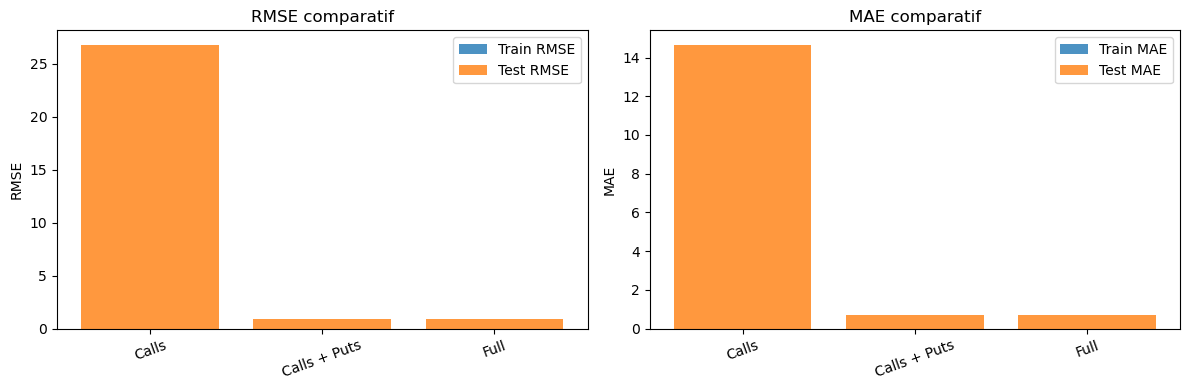

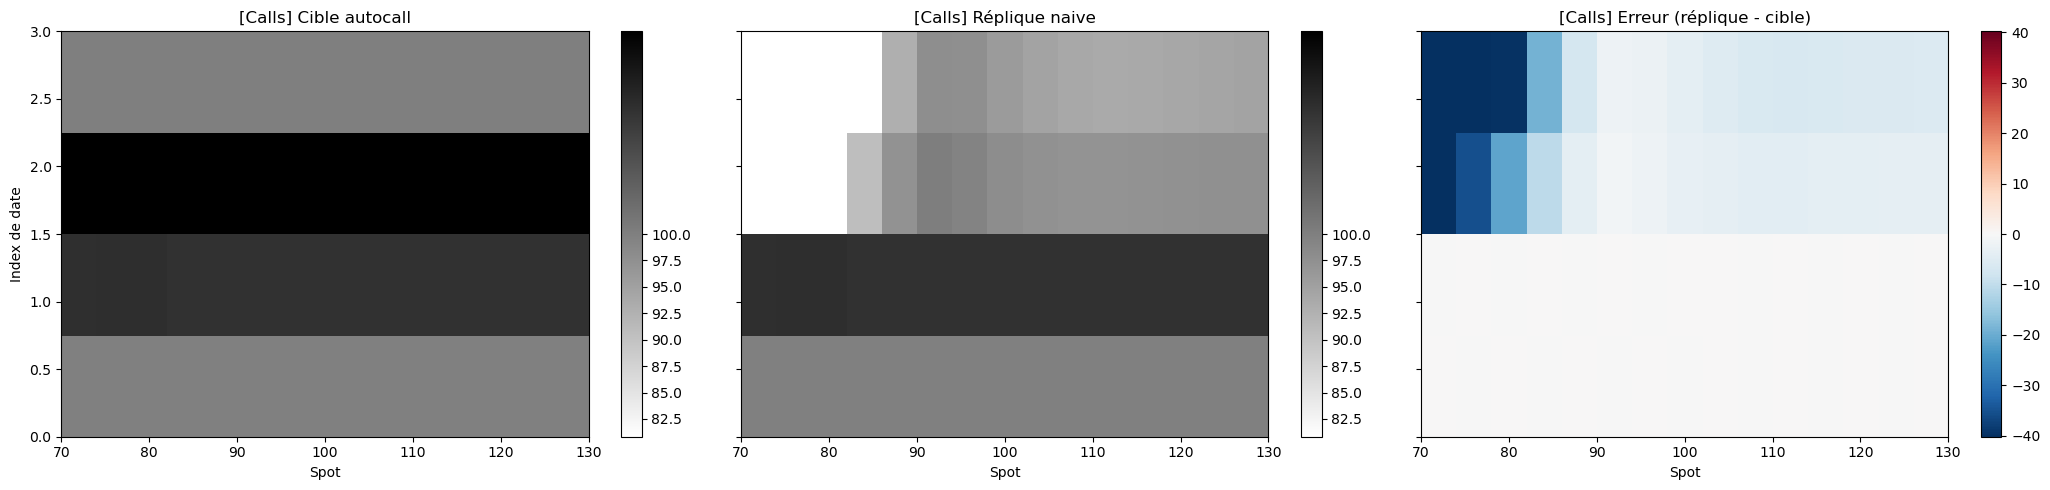

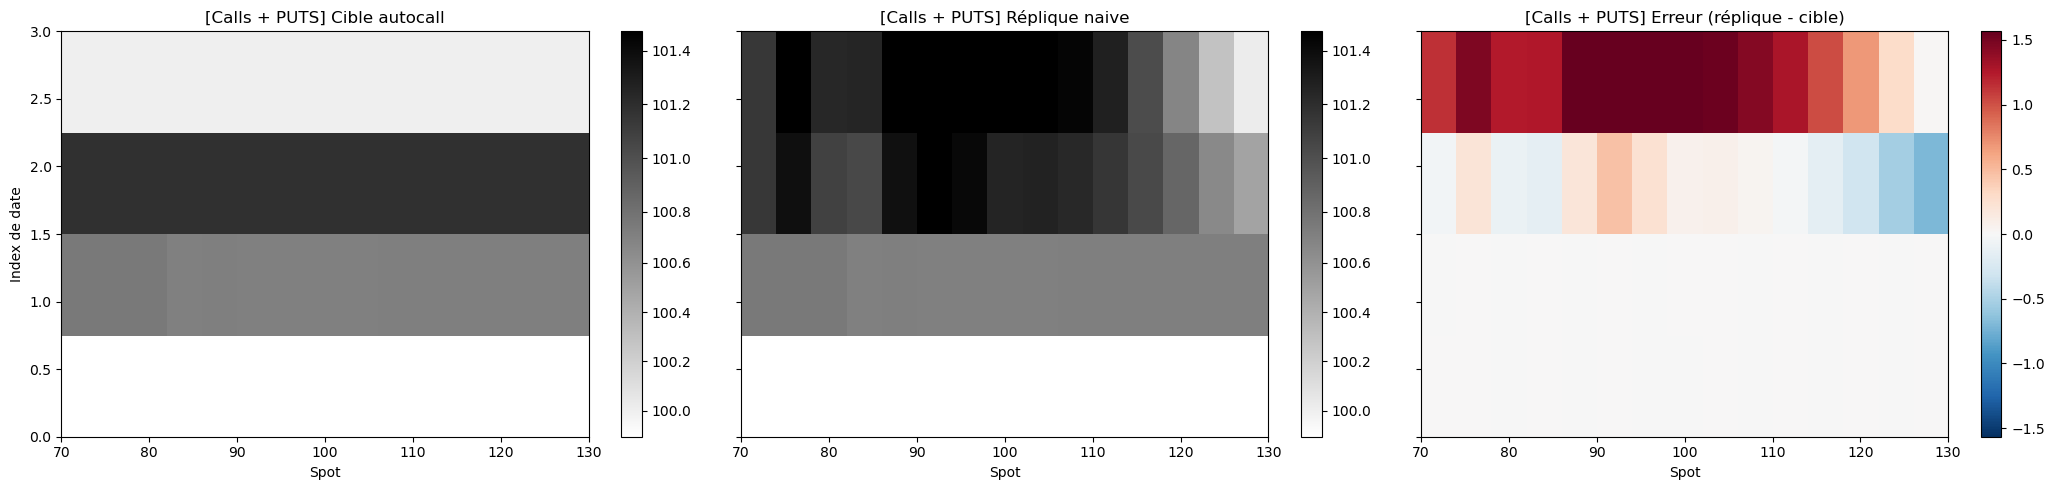

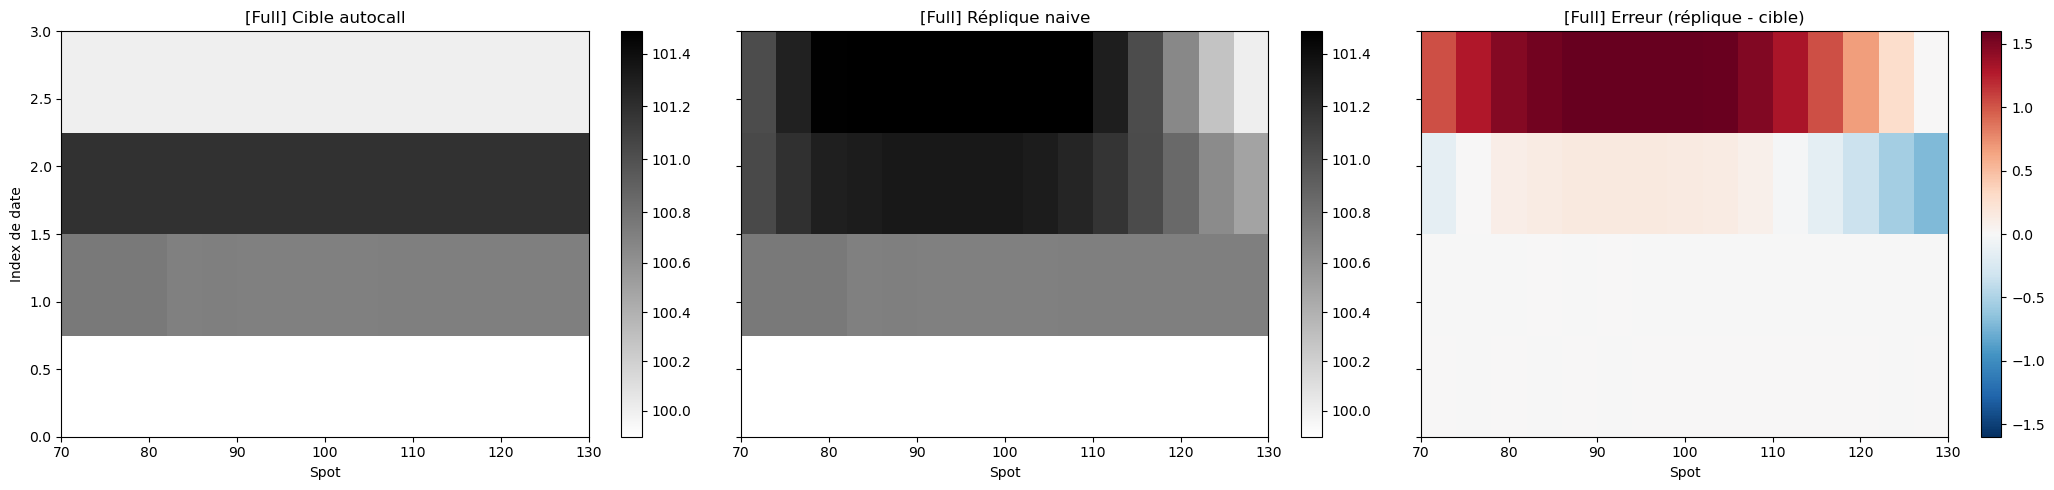

In [382]:
comparative_table = pd.DataFrame([
    {
        "family": "calls",
        "train_mae": res_calls["metrics_train"]["mae"],
        "train_rmse": res_calls["metrics_train"]["rmse"],
        "train_max_abs_error": res_calls["metrics_train"]["max_abs_error"],
        "train_mean_error": res_calls["metrics_train"]["mean_error"],
        "test_mae": res_calls["metrics_test"].get("mae", np.nan),
        "test_rmse": res_calls["metrics_test"].get("rmse", np.nan),
        "test_max_abs_error": res_calls["metrics_test"].get("max_abs_error", np.nan),
        "test_mean_error": res_calls["metrics_test"].get("mean_error", np.nan),
    },
    {
        "family": "calls_puts",
        "train_mae": res_calls_puts["metrics_train"]["mae"],
        "train_rmse": res_calls_puts["metrics_train"]["rmse"],
        "train_max_abs_error": res_calls_puts["metrics_train"]["max_abs_error"],
        "train_mean_error": res_calls_puts["metrics_train"]["mean_error"],
        "test_mae": res_calls_puts["metrics_test"].get("mae", np.nan),
        "test_rmse": res_calls_puts["metrics_test"].get("rmse", np.nan),
        "test_max_abs_error": res_calls_puts["metrics_test"].get("max_abs_error", np.nan),
        "test_mean_error": res_calls_puts["metrics_test"].get("mean_error", np.nan),
    },
    {
        "family": "full",
        "train_mae": res_full["metrics_train"]["mae"],
        "train_rmse": res_full["metrics_train"]["rmse"],
        "train_max_abs_error": res_full["metrics_train"]["max_abs_error"],
        "train_mean_error": res_full["metrics_train"]["mean_error"],
        "test_mae": res_full["metrics_test"].get("mae", np.nan),
        "test_rmse": res_full["metrics_test"].get("rmse", np.nan),
        "test_max_abs_error": res_full["metrics_test"].get("max_abs_error", np.nan),
        "test_mean_error": res_full["metrics_test"].get("mean_error", np.nan),
    },
])
pd.reset_option("display.float_format")
display(comparative_table)

metrics_plot = comparative_table.copy()
metrics_plot["family"] = ["Calls", "Calls + Puts", "Full"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True)

# Train RMSE / Test RMSE
axes[0].bar(metrics_plot["family"], metrics_plot["train_rmse"], label="Train RMSE", alpha=0.8)
axes[0].bar(metrics_plot["family"], metrics_plot["test_rmse"], label="Test RMSE", alpha=0.8)
axes[0].set_title("RMSE comparatif")
axes[0].set_ylabel("RMSE")
axes[0].tick_params(axis="x", rotation=20)
axes[0].legend()

# Train MAE / Test MAE
axes[1].bar(metrics_plot["family"], metrics_plot["train_mae"], label="Train MAE", alpha=0.8)
axes[1].bar(metrics_plot["family"], metrics_plot["test_mae"], label="Test MAE", alpha=0.8)
axes[1].set_title("MAE comparatif")
axes[1].set_ylabel("MAE")
axes[1].tick_params(axis="x", rotation=20)
axes[1].legend()

plt.tight_layout()
plt.show()

plot_benchmark_surface(res_calls["dates"],res_calls["spots"],res_calls["target_tensor"],res_calls["fitted_tensor"], title_prefix="[Calls] ")
plot_benchmark_surface(res_calls_puts["dates"],res_calls_puts["spots"],res_calls_puts["target_tensor"],res_calls_puts["fitted_tensor"], title_prefix="[Calls + PUTS] ")
plot_benchmark_surface(res_full["dates"],res_full["spots"],res_full["target_tensor"],res_full["fitted_tensor"], title_prefix="[Full] ")

,family,train_mae,train_rmse,train_max_abs_error,train_mean_error,test_mae,test_rmse,test_max_abs_error,test_mean_error
0,calls_puts,8.252604e-07,1.305159e-06,3.316422e-06,-1.054914e-10,0.715977,0.953229,1.921792,0.582313
1,full,4.685135e-09,8.425424e-09,3.091405e-08,-1.043735e-10,0.701440,0.942525,1.621478,0.575078


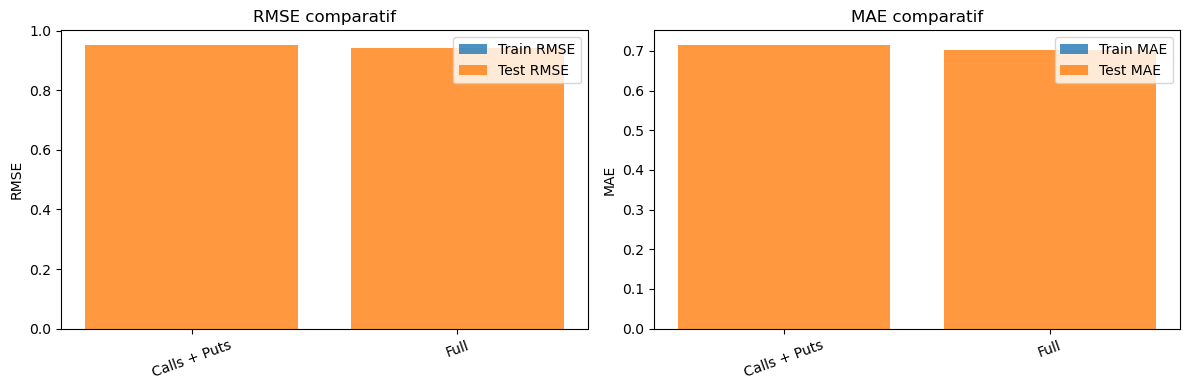

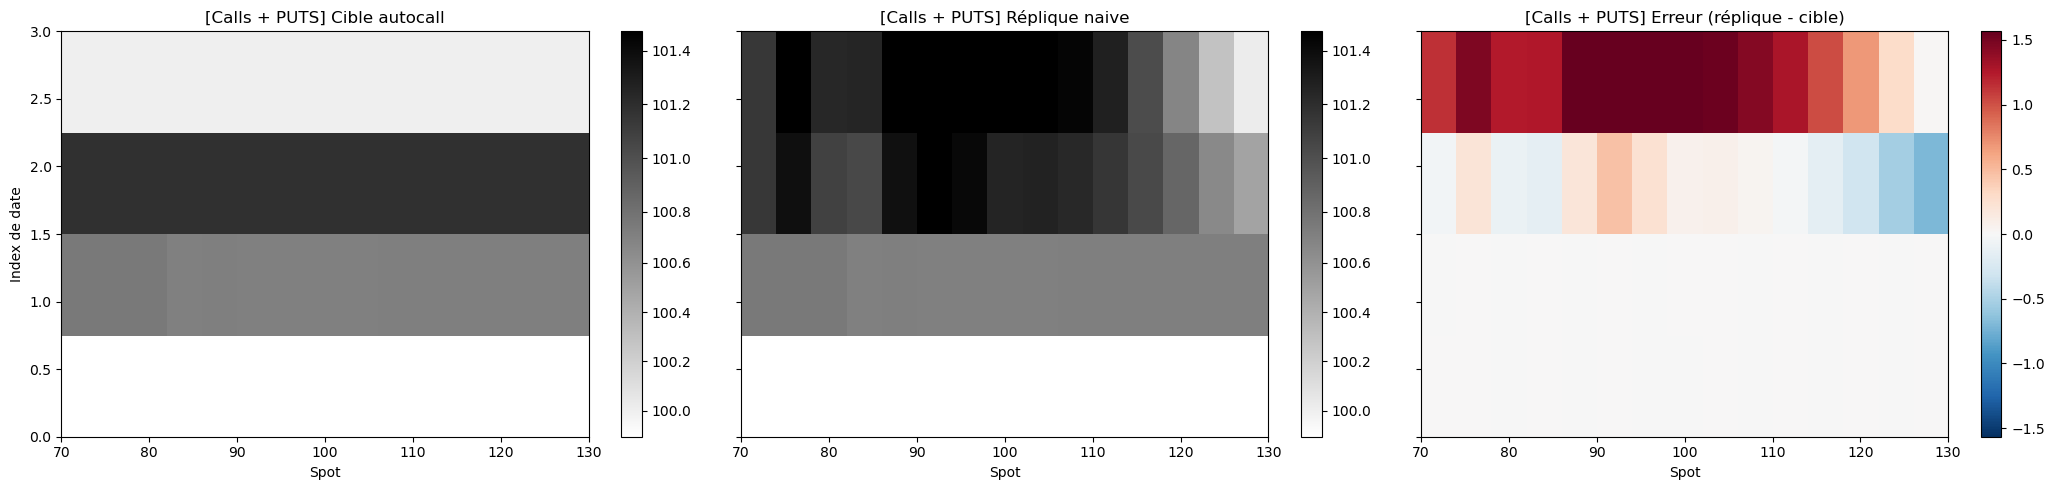

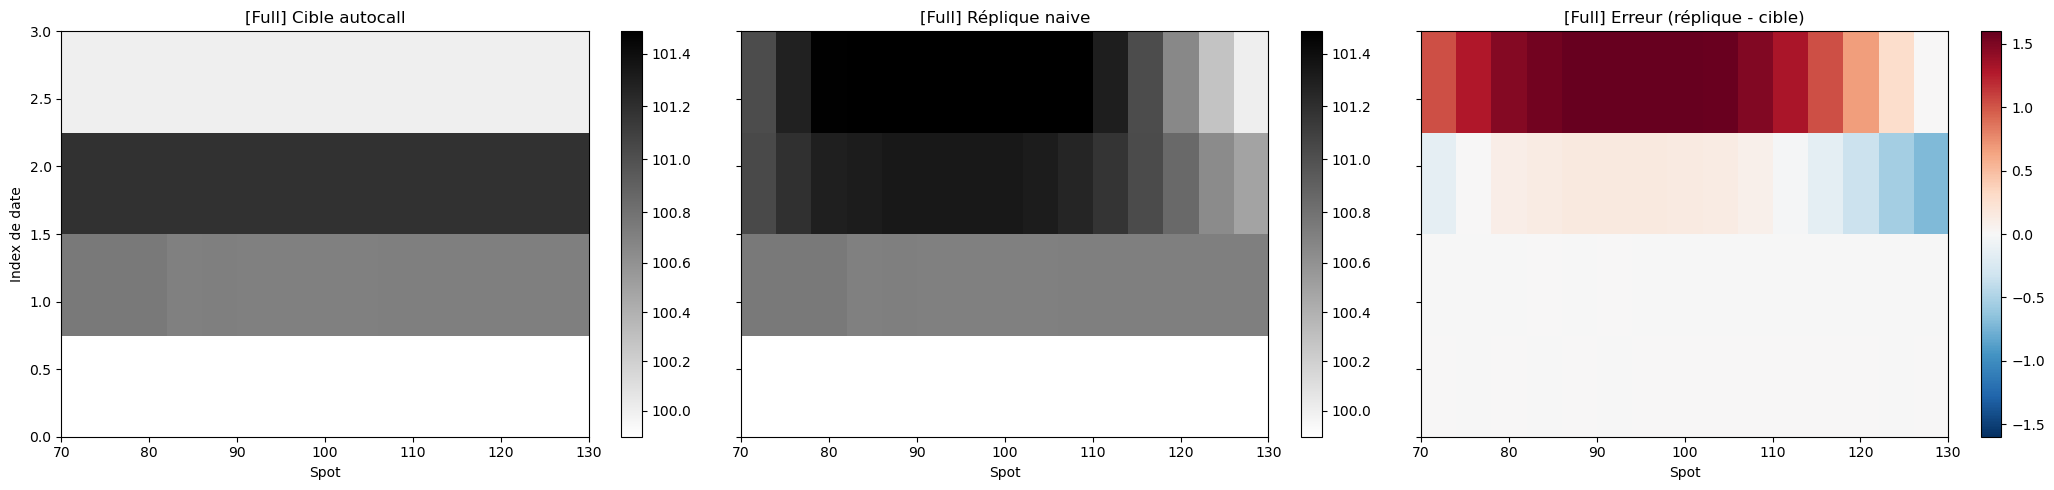

In [383]:
#tout sans le call 
# ============================================================
# EXEMPLES D'UTILISATION
# ============================================================
comparative_table = pd.DataFrame([
    {
        "family": "calls_puts",
        "train_mae": res_calls_puts["metrics_train"]["mae"],
        "train_rmse": res_calls_puts["metrics_train"]["rmse"],
        "train_max_abs_error": res_calls_puts["metrics_train"]["max_abs_error"],
        "train_mean_error": res_calls_puts["metrics_train"]["mean_error"],
        "test_mae": res_calls_puts["metrics_test"].get("mae", np.nan),
        "test_rmse": res_calls_puts["metrics_test"].get("rmse", np.nan),
        "test_max_abs_error": res_calls_puts["metrics_test"].get("max_abs_error", np.nan),
        "test_mean_error": res_calls_puts["metrics_test"].get("mean_error", np.nan),
    },
    {
        "family": "full",
        "train_mae": res_full["metrics_train"]["mae"],
        "train_rmse": res_full["metrics_train"]["rmse"],
        "train_max_abs_error": res_full["metrics_train"]["max_abs_error"],
        "train_mean_error": res_full["metrics_train"]["mean_error"],
        "test_mae": res_full["metrics_test"].get("mae", np.nan),
        "test_rmse": res_full["metrics_test"].get("rmse", np.nan),
        "test_max_abs_error": res_full["metrics_test"].get("max_abs_error", np.nan),
        "test_mean_error": res_full["metrics_test"].get("mean_error", np.nan),
    },
])
pd.reset_option("display.float_format")
display(comparative_table)

metrics_plot = comparative_table.copy()
metrics_plot["family"] = ["Calls + Puts", "Full"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True)

# Train RMSE / Test RMSE
axes[0].bar(metrics_plot["family"], metrics_plot["train_rmse"], label="Train RMSE", alpha=0.8)
axes[0].bar(metrics_plot["family"], metrics_plot["test_rmse"], label="Test RMSE", alpha=0.8)
axes[0].set_title("RMSE comparatif")
axes[0].set_ylabel("RMSE")
axes[0].tick_params(axis="x", rotation=20)
axes[0].legend()

# Train MAE / Test MAE
axes[1].bar(metrics_plot["family"], metrics_plot["train_mae"], label="Train MAE", alpha=0.8)
axes[1].bar(metrics_plot["family"], metrics_plot["test_mae"], label="Test MAE", alpha=0.8)
axes[1].set_title("MAE comparatif")
axes[1].set_ylabel("MAE")
axes[1].tick_params(axis="x", rotation=20)
axes[1].legend()

plt.tight_layout()
plt.show()

plot_benchmark_surface(res_calls_puts["dates"],res_calls_puts["spots"],res_calls_puts["target_tensor"],res_calls_puts["fitted_tensor"], title_prefix="[Calls + PUTS] ")
plot_benchmark_surface(res_full["dates"],res_full["spots"],res_full["target_tensor"],res_full["fitted_tensor"], title_prefix="[Full] ")

=== CALLS ===
Train: {'mae': 2.063928100947502e-05, 'rmse': 3.420424132687624e-05, 'max_abs_error': 0.00010121653041039735, 'mean_error': -7.57882820797325e-08}
Test : {'mae': 19.88572767415918, 'rmse': 28.632069390596747, 'max_abs_error': 100.0, 'mean_error': -19.88572767415918}


,name,kind,maturity_date,strike,weight
143,C_20270620_70.00,EuropeanCall,2027-06-20,70.0,7.119162
130,C_20270520_70.00,EuropeanCall,2027-05-20,70.0,6.103746
117,C_20270420_70.00,EuropeanCall,2027-04-20,70.0,5.019409
65,C_20261220_70.00,EuropeanCall,2026-12-20,70.0,-4.106105
104,C_20270320_70.00,EuropeanCall,2027-03-20,70.0,3.746850
52,C_20261120_70.00,EuropeanCall,2026-11-20,70.0,-3.494424
144,C_20270620_75.00,EuropeanCall,2027-06-20,75.0,2.973311
39,C_20261020_70.00,EuropeanCall,2026-10-20,70.0,-2.887297
66,C_20261220_75.00,EuropeanCall,2026-12-20,75.0,-2.769111
26,C_20260920_70.00,EuropeanCall,2026-09-20,70.0,-2.409088


=== CALLS + PUTS ===
Train: {'mae': 9.088016622627037e-06, 'rmse': 1.6851980252009713e-05, 'max_abs_error': 4.986824326635997e-05, 'mean_error': -1.1422211324922198e-10}
Test : {'mae': 1.0387495211425786, 'rmse': 1.2792771701787375, 'max_abs_error': 2.551022289678258, 'mean_error': 0.5511911096169716}


,name,kind,maturity_date,strike,weight
94,C_20261020_110.00,EuropeanCall,2026-10-20,110.0,-0.371828
99,P_20261020_120.00,EuropeanPut,2026-10-20,120.0,0.345814
95,P_20261020_110.00,EuropeanPut,2026-10-20,110.0,-0.344571
98,C_20261020_120.00,EuropeanCall,2026-10-20,120.0,0.284309
150,C_20261220_120.00,EuropeanCall,2026-12-20,120.0,-0.217894
172,C_20270120_110.00,EuropeanCall,2027-01-20,110.0,-0.214673
177,P_20270120_120.00,EuropeanPut,2027-01-20,120.0,0.214454
147,P_20261220_110.00,EuropeanPut,2026-12-20,110.0,0.204713
173,P_20270120_110.00,EuropeanPut,2027-01-20,110.0,-0.173063
96,C_20261020_115.00,EuropeanCall,2026-10-20,115.0,-0.168923


=== FULL ===
Train: {'mae': 6.002818035237093e-09, 'rmse': 9.803742220272486e-09, 'max_abs_error': 3.3529985898894665e-08, 'mean_error': -1.1330835529103448e-10}
Test : {'mae': 0.9877888738058985, 'rmse': 1.2331204821357105, 'max_abs_error': 1.9967548649260465, 'mean_error': 0.6519922279309001}


,name,kind,maturity_date,strike,weight
52,C_20260820_70.00,EuropeanCall,2026-08-20,70.0,0.116246
104,C_20260920_70.00,EuropeanCall,2026-09-20,70.0,0.116246
0,C_20260720_70.00,EuropeanCall,2026-07-20,70.0,0.116244
153,P_20260920_130.00,EuropeanPut,2026-09-20,130.0,0.087815
101,P_20260820_130.00,EuropeanPut,2026-08-20,130.0,0.087814
49,P_20260720_130.00,EuropeanPut,2026-07-20,130.0,0.087811
261,P_20261220_70.00,EuropeanPut,2026-12-20,70.0,-0.084727
308,C_20261220_130.00,EuropeanCall,2026-12-20,130.0,-0.077313
621,P_20270620_130.00,EuropeanPut,2027-06-20,130.0,0.072101
209,P_20261120_70.00,EuropeanPut,2026-11-20,70.0,-0.070503


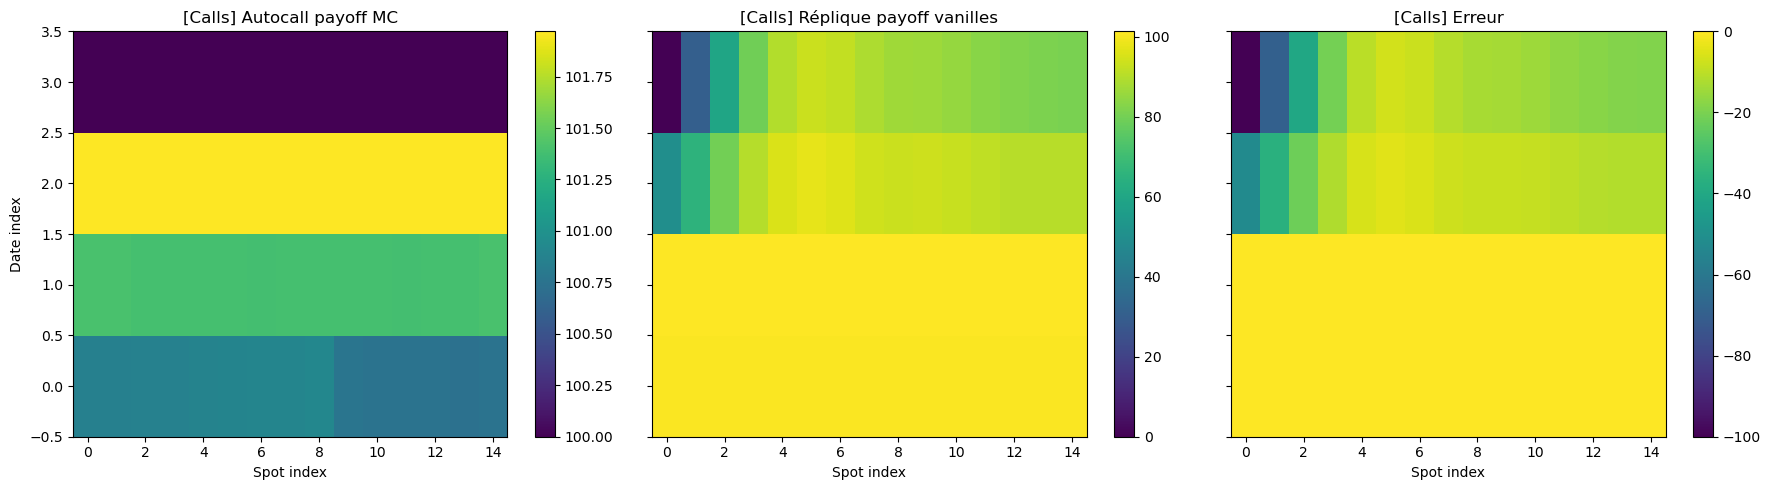

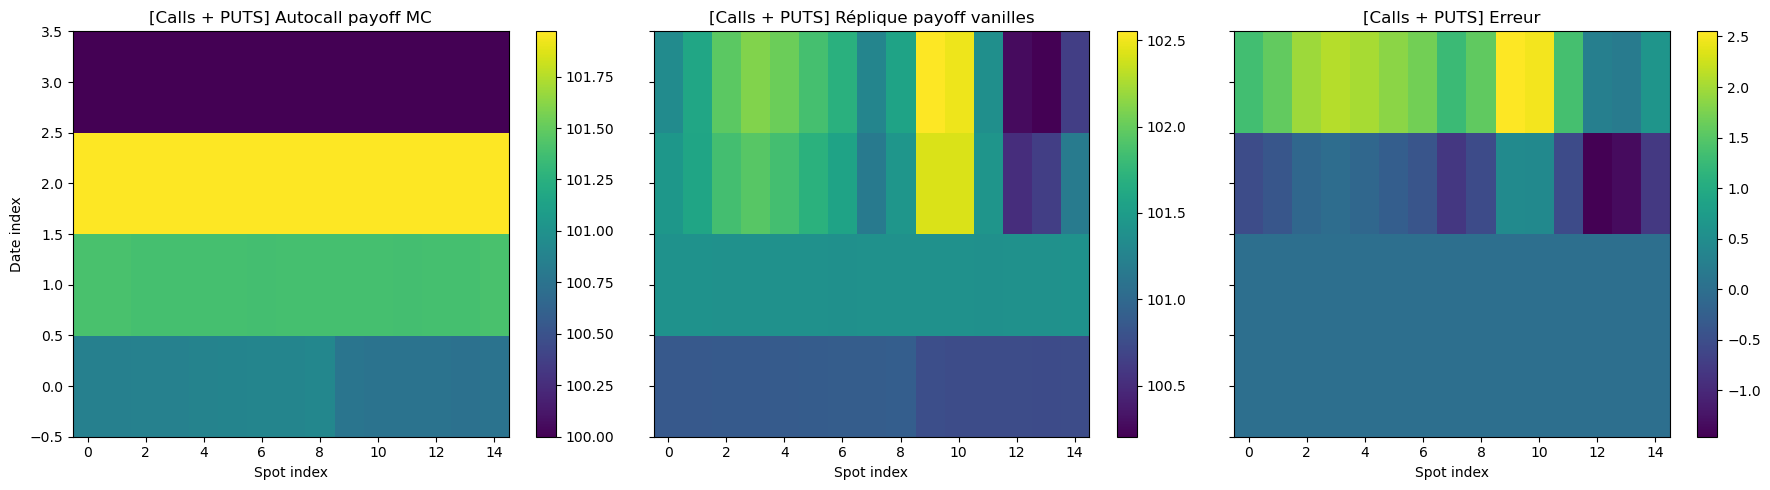

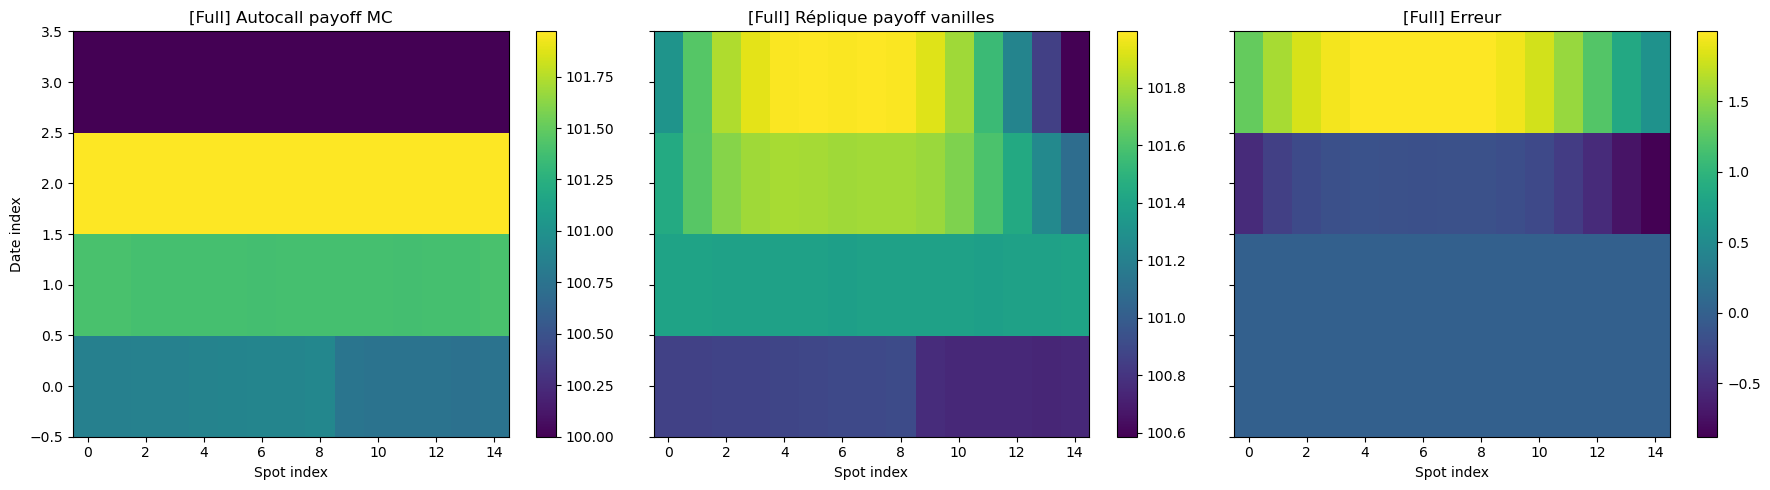

In [385]:
# ============================================================
# BENCHMARK PAYOFF : autocall vs portefeuille de vanilles
# ============================================================

# ------------------------------------------------------------
# 1) Cible : espérance du payoff brut de l'autocall sur une grille
# ------------------------------------------------------------
def autocall_meanpayoff_on_grid_mc(
    product: AutocallProduct,
    dates: pd.DatetimeIndex,
    spots: np.ndarray,
    maturity_date: str | pd.Timestamp,
    rate: float,
    dividend_yield: float,
    vol: float,
    n_paths: int = 300,
    seed: int = 42,
) -> np.ndarray:
    """
    Retourne une matrice (len(dates), len(spots)) avec la moyenne MC
    du payoff brut de l'autocall pour chaque point de la grille.
    """
    maturity_date = pd.Timestamp(maturity_date)
    target = np.empty((len(dates), len(spots)), dtype=float)

    for i, d in enumerate(dates):
        d = pd.Timestamp(d)
        for j, s in enumerate(spots):
            out = target_meanpayoff_mc(
                product=product,
                spot0=float(s),
                valuation_date=d,
                maturity_date=maturity_date,
                rate=rate,
                dividend_yield=dividend_yield,
                vol=vol,
                n_paths=n_paths,
                seed=seed + 1000 * i + j,
            )
            target[i, j] = out["mean_undiscounted_payoff"]

    return target


# ------------------------------------------------------------
# 2) Réplique : espérance de payoff brut du portefeuille de vanilles
# ------------------------------------------------------------
def vanilla_basis_expected_payoff_on_grid(
    vanillas: list[VanillaProduct],
    dates: pd.DatetimeIndex,
    spots: np.ndarray,
    rate: float,
    dividend_yield: float,
    vol: float,
) -> np.ndarray:
    """
    Retourne une matrice A de taille (len(dates) * len(spots), len(vanillas))
    contenant, pour chaque point de grille, l'espérance du payoff brut
    de chaque vanille.
    """
    n_obs = len(dates) * len(spots)
    A = np.empty((n_obs, len(vanillas)), dtype=float)

    row = 0
    for d in dates:
        d = pd.Timestamp(d)
        for s in spots:
            s = float(s)
            for j, v in enumerate(vanillas):
                tau = v.time_to_maturity(d)

                if tau <= 0:
                    A[row, j] = v.payoff(s)
                else:
                    price = v.price_bs(
                        spot=s,
                        valuation_date=d,
                        rate=rate,
                        dividend_yield=dividend_yield,
                        vol=vol,
                    )
                    A[row, j] = price * np.exp(rate * tau)

            row += 1

    return A


# ------------------------------------------------------------
# 3) Pipeline complet : fit sur payoff brut
# ------------------------------------------------------------
def run_naive_benchmark_payoff(
    product: AutocallProduct,
    spot0: float,
    valuation_date: str | pd.Timestamp,
    maturity_date: str | pd.Timestamp,
    rate: float,
    dividend_yield: float,
    vol: float,
    family: str,
    n_spots: int = 15,
    n_paths: int = 3000,
    spot_min_mult: float = 0.70,
    spot_max_mult: float = 1.30,
    l2: float = 1e-8,
    train_frac: float = 0.7,
    seed: int = 42,
) -> dict[str, object]:
    valuation_date = pd.Timestamp(valuation_date)
    maturity_date = pd.Timestamp(maturity_date)

    dates, spots = build_autocall_training_grid_axes(
        spot0=spot0,
        valuation_date=valuation_date,
        maturity_date=maturity_date,
        n_spots=n_spots,
        spot_min_mult=spot_min_mult,
        spot_max_mult=spot_max_mult,
        include_call_dates=True,
        product=product,
    )

    target_tensor = autocall_meanpayoff_on_grid_mc(
        product=product,
        dates=dates,
        spots=spots,
        maturity_date=maturity_date,
        rate=rate,
        dividend_yield=dividend_yield,
        vol=vol,
        n_paths=n_paths,
        seed=seed,
    )
    y = target_tensor.reshape(-1)

    vanillas = build_naive_vanilla_basis(
        spot0=spot0,
        valuation_date=valuation_date,
        maturity_date=maturity_date,
        product=product,
        strike_step=5.0,
        strike_min_mult=0.70,
        strike_max_mult=1.30,
        family=family,
    )

    A = vanilla_basis_expected_payoff_on_grid(
        vanillas=vanillas,
        dates=dates,
        spots=spots,
        rate=rate,
        dividend_yield=dividend_yield,
        vol=vol,
    )

    n_dates = len(dates)
    split = max(1, int(train_frac * n_dates))

    idx_train = np.arange(split * len(spots))
    idx_test = np.arange(split * len(spots), n_dates * len(spots))

    A_train, y_train = A[idx_train], y[idx_train]
    A_test, y_test = A[idx_test], y[idx_test]

    w = fit_ridge(A_train, y_train, l2=l2)

    pred_train = A_train @ w
    pred_test = A_test @ w

    metrics_train = benchmark_metrics(y_train, pred_train)
    metrics_test = benchmark_metrics(y_test, pred_test) if len(idx_test) > 0 else {}

    weights = pd.DataFrame(
        {
            "name": [v.name for v in vanillas],
            "kind": [v.__class__.__name__ for v in vanillas],
            "maturity_date": [pd.Timestamp(v.maturity_date) for v in vanillas],
            "strike": [float(v.strike) for v in vanillas],
            "weight": w,
        }
    ).sort_values("weight", key=lambda s: s.abs(), ascending=False)

    fitted_tensor = (A @ w).reshape(target_tensor.shape)

    return {
        "dates": dates,
        "spots": spots,
        "target_tensor": target_tensor,
        "fitted_tensor": fitted_tensor,
        "vanillas": vanillas,
        "weights": weights,
        "metrics_train": metrics_train,
        "metrics_test": metrics_test,
        "family": family,
        "A": A,
        "w": w,
    }


# ------------------------------------------------------------
# 4) Affichage
# ------------------------------------------------------------
def plot_payoff_benchmark_surface(
    dates: pd.DatetimeIndex,
    spots: np.ndarray,
    target_tensor: np.ndarray,
    fitted_tensor: np.ndarray,
    title_prefix: str = "",
):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

    im0 = axes[0].imshow(target_tensor, aspect="auto", origin="lower")
    axes[0].set_title(f"{title_prefix}Autocall payoff MC")
    axes[0].set_xlabel("Spot index")
    axes[0].set_ylabel("Date index")
    plt.colorbar(im0, ax=axes[0])

    im1 = axes[1].imshow(fitted_tensor, aspect="auto", origin="lower")
    axes[1].set_title(f"{title_prefix}Réplique payoff vanilles")
    axes[1].set_xlabel("Spot index")
    plt.colorbar(im1, ax=axes[1])

    im2 = axes[2].imshow(fitted_tensor - target_tensor, aspect="auto", origin="lower")
    axes[2].set_title(f"{title_prefix}Erreur")
    axes[2].set_xlabel("Spot index")
    plt.colorbar(im2, ax=axes[2])

    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------
# 5) Exécution
# ------------------------------------------------------------
res_payoff_calls = run_naive_benchmark_payoff(
    product=prod,
    spot0=spot0,
    valuation_date=valuation_date,
    maturity_date=maturity_date,
    rate=rate,
    dividend_yield=dividend_yield,
    vol=vol,
    family="calls",
    n_spots=15,
    n_paths=200,
    l2=1e-6,
)

res_payoff_calls_puts = run_naive_benchmark_payoff(
    product=prod,
    spot0=spot0,
    valuation_date=valuation_date,
    maturity_date=maturity_date,
    rate=rate,
    dividend_yield=dividend_yield,
    vol=vol,
    family="calls_puts",
    n_spots=15,
    n_paths=200,
    l2=1e-6,
)

res_payoff_full = run_naive_benchmark_payoff(
    product=prod,
    spot0=spot0,
    valuation_date=valuation_date,
    maturity_date=maturity_date,
    rate=rate,
    dividend_yield=dividend_yield,
    vol=vol,
    family="full",
    n_spots=15,
    n_paths=200,
    l2=1e-6,
)

print("=== CALLS ===")
print("Train:", res_payoff_calls["metrics_train"])
print("Test :", res_payoff_calls["metrics_test"])
display(res_payoff_calls["weights"].head(10))

print("=== CALLS + PUTS ===")
print("Train:", res_payoff_calls_puts["metrics_train"])
print("Test :", res_payoff_calls_puts["metrics_test"])
display(res_payoff_calls_puts["weights"].head(10))

print("=== FULL ===")
print("Train:", res_payoff_full["metrics_train"])
print("Test :", res_payoff_full["metrics_test"])
display(res_payoff_full["weights"].head(10))

plot_payoff_benchmark_surface(
    res_payoff_calls["dates"],
    res_payoff_calls["spots"],
    res_payoff_calls["target_tensor"],
    res_payoff_calls["fitted_tensor"],
    title_prefix="[Calls] ",
)

plot_payoff_benchmark_surface(
    res_payoff_calls_puts["dates"],
    res_payoff_calls_puts["spots"],
    res_payoff_calls_puts["target_tensor"],
    res_payoff_calls_puts["fitted_tensor"],
    title_prefix="[Calls + PUTS] ",
)

plot_payoff_benchmark_surface(
    res_payoff_full["dates"],
    res_payoff_full["spots"],
    res_payoff_full["target_tensor"],
    res_payoff_full["fitted_tensor"],
    title_prefix="[Full] ",
)

In [388]:
# ============================================================
# BENCHMARK PAYOFF PATHWISE : mêmes trajectoires pour tout
# ============================================================

def autocall_discounted_payoff_from_path(
    product: AutocallProduct,
    path: pd.Series,
    valuation_date: str | pd.Timestamp,
    rate: float,
) -> float:
    """
    Calcule la valeur actualisée de l'autocall sur une trajectoire donnée.

    On simule une seule trajectoire, puis on actualise tous les cashflows à la
    date de valorisation.
    """
    valuation_date = pd.Timestamp(valuation_date)
    res = product.compute_autocall_payoff(path, start_date=valuation_date)

    pv = 0.0
    for _, row in res["cashflows"].iterrows():
        t = _year_fraction(valuation_date, pd.Timestamp(row["date"]))
        pv += float(row["amount"]) * math.exp(-rate * t)

    return pv


def vanilla_discounted_payoff_from_path(
    vanilla: VanillaProduct,
    path: pd.Series,
    valuation_date: str | pd.Timestamp,
    rate: float,
) -> float:
    """
    Calcule la valeur actualisée d'une vanille sur une trajectoire donnée.

    La vanille paie à sa propre maturité.
    """
    valuation_date = pd.Timestamp(valuation_date)
    maturity_date = pd.Timestamp(vanilla.maturity_date)
    tau = _year_fraction(valuation_date, maturity_date)

    if tau <= 0:
        # Cas purement défensif : maturité déjà passée.
        s_T = float(path.iloc[0])
        return float(vanilla.payoff(s_T))

    s_T = float(path.loc[path.index <= maturity_date].iloc[-1])
    payoff = float(vanilla.payoff(s_T))
    return payoff * math.exp(-rate * tau)


def build_pathwise_payoff_dataset(
    product: AutocallProduct,
    vanillas: list[VanillaProduct],
    spot0: float,
    valuation_date: str | pd.Timestamp,
    maturity_date: str | pd.Timestamp,
    rate: float,
    dividend_yield: float,
    vol: float,
    n_paths: int = 3000,
    seed: int = 42,
) -> tuple[np.ndarray, np.ndarray]:
    """
    Construit le dataset de régression pathwise.

    Sortie :
    - X : matrice (n_paths, n_vanillas) avec les payoffs actualisés des vanilles
         calculés sur les mêmes trajectoires.
    - y : vecteur (n_paths,) avec le payoff actualisé de l'autocall.
    """
    valuation_date = pd.Timestamp(valuation_date)
    maturity_date = pd.Timestamp(maturity_date)

    X = np.empty((n_paths, len(vanillas)), dtype=float)
    y = np.empty(n_paths, dtype=float)

    for p in range(n_paths):
        seed_p = None if seed is None else seed + p

        # Une seule trajectoire sert à la fois pour la cible et pour les features.
        path = simulate_gbm_path(
            spot0=spot0,
            start_date=valuation_date,
            end_date=maturity_date,
            rate=rate,
            dividend_yield=dividend_yield,
            vol=vol,
            seed=seed_p,
        )

        y[p] = autocall_discounted_payoff_from_path(
            product=product,
            path=path,
            valuation_date=valuation_date,
            rate=rate,
        )

        for j, v in enumerate(vanillas):
            X[p, j] = vanilla_discounted_payoff_from_path(
                vanilla=v,
                path=path,
                valuation_date=valuation_date,
                rate=rate,
            )

    return X, y


def run_naive_benchmark_payoff_pathwise(
    product: AutocallProduct,
    spot0: float,
    valuation_date: str | pd.Timestamp,
    maturity_date: str | pd.Timestamp,
    rate: float,
    dividend_yield: float,
    vol: float,
    family: str,
    n_paths: int = 3000,
    spot_min_mult: float = 0.70,
    spot_max_mult: float = 1.30,
    l2: float = 1e-8,
    train_frac: float = 0.7,
    seed: int = 42,
) -> dict[str, object]:
    """
    Benchmark pathwise :
    - cible = payoff actualisé de l'autocall sur chaque trajectoire
    - features = payoffs actualisés des vanilles sur les mêmes trajectoires

    C'est la version la plus fidèle si tu veux tester la qualité de réplication.
    """
    valuation_date = pd.Timestamp(valuation_date)
    maturity_date = pd.Timestamp(maturity_date)

    vanillas = build_naive_vanilla_basis(
        spot0=spot0,
        valuation_date=valuation_date,
        maturity_date=maturity_date,
        product=product,
        strike_step=5.0,
        strike_min_mult=spot_min_mult,
        strike_max_mult=spot_max_mult,
        family=family,
    )

    X, y = build_pathwise_payoff_dataset(
        product=product,
        vanillas=vanillas,
        spot0=spot0,
        valuation_date=valuation_date,
        maturity_date=maturity_date,
        rate=rate,
        dividend_yield=dividend_yield,
        vol=vol,
        n_paths=n_paths,
        seed=seed,
    )

    split = max(1, int(train_frac * n_paths))
    X_train, y_train = X[:split], y[:split]
    X_test, y_test = X[split:], y[split:]

    w = fit_ridge(X_train, y_train, l2=l2)

    pred_train = X_train @ w
    pred_test = X_test @ w if len(X_test) > 0 else np.array([])

    metrics_train = benchmark_metrics(y_train, pred_train)
    metrics_test = benchmark_metrics(y_test, pred_test) if len(X_test) > 0 else {}

    weights = pd.DataFrame(
        {
            "name": [v.name for v in vanillas],
            "kind": [v.__class__.__name__ for v in vanillas],
            "maturity_date": [pd.Timestamp(v.maturity_date) for v in vanillas],
            "strike": [float(v.strike) for v in vanillas],
            "weight": w,
        }
    ).sort_values("weight", key=lambda s: s.abs(), ascending=False)

    replica = X @ w
    error = replica - y

    return {
        "vanillas": vanillas,
        "X": X,
        "y": y,
        "replica": replica,
        "error": error,
        "weights": weights,
        "metrics_train": metrics_train,
        "metrics_test": metrics_test,
        "family": family,
        "w": w,
    }


def plot_pathwise_benchmark(
    y: np.ndarray,
    replica: np.ndarray,
    title_prefix: str = "",
):
    """
    Compare cible et réplique sur les mêmes trajectoires.
    """
    y = np.asarray(y, dtype=float).reshape(-1)
    replica = np.asarray(replica, dtype=float).reshape(-1)
    err = replica - y

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # 1) Scatter cible vs réplique
    axes[0].scatter(y, replica, alpha=0.5, s=15)
    lo = min(y.min(), replica.min())
    hi = max(y.max(), replica.max())
    axes[0].plot([lo, hi], [lo, hi], linestyle="--")
    axes[0].set_title(f"{title_prefix}Cible vs réplique")
    axes[0].set_xlabel("Payoff actualisé autocall")
    axes[0].set_ylabel("Payoff actualisé réplique")

    # 2) Distribution de l'erreur
    axes[1].hist(err, bins=40)
    axes[1].set_title(f"{title_prefix}Distribution de l'erreur")
    axes[1].set_xlabel("Réplique - cible")
    axes[1].set_ylabel("Fréquence")

    plt.tight_layout()
    plt.show()

Train: {'mae': 2.270711558255123, 'rmse': 4.334224832089989, 'max_abs_error': 30.7845548009644, 'mean_error': -5.479909016717751e-09}
Test : {'mae': 2.322099391474754, 'rmse': 4.756478142338851, 'max_abs_error': 36.84771413734552, 'mean_error': -0.018035302333589343}


,name,kind,maturity_date,strike,weight
1,C_20260720_75.00,EuropeanCall,2026-07-20,75.0,-20.299152
0,C_20260720_70.00,EuropeanCall,2026-07-20,70.0,17.917327
14,C_20260820_75.00,EuropeanCall,2026-08-20,75.0,4.767076
13,C_20260820_70.00,EuropeanCall,2026-08-20,70.0,-4.639815
2,C_20260720_80.00,EuropeanCall,2026-07-20,80.0,3.897255
144,C_20270620_75.00,EuropeanCall,2027-06-20,75.0,-2.702410
143,C_20270620_70.00,EuropeanCall,2027-06-20,70.0,2.610103
3,C_20260720_85.00,EuropeanCall,2026-07-20,85.0,-2.269094
40,C_20261020_75.00,EuropeanCall,2026-10-20,75.0,1.773306
130,C_20270520_70.00,EuropeanCall,2027-05-20,70.0,1.672202


Train: {'mae': 2.121959525475475, 'rmse': 4.056883641718745, 'max_abs_error': 30.541902272281646, 'mean_error': -2.577133427296628e-12}
Test : {'mae': 2.369509483769845, 'rmse': 5.196500877357945, 'max_abs_error': 44.9253887285502, 'mean_error': -0.06700523670145407}


,name,kind,maturity_date,strike,weight
53,P_20260920_70.00,EuropeanPut,2026-09-20,70.0,-1.412277
52,C_20260920_70.00,EuropeanCall,2026-09-20,70.0,-1.147131
289,P_20270620_75.00,EuropeanPut,2027-06-20,75.0,-0.876730
81,P_20261020_75.00,EuropeanPut,2026-10-20,75.0,0.811387
80,C_20261020_75.00,EuropeanCall,2026-10-20,75.0,0.810578
104,C_20261120_70.00,EuropeanCall,2026-11-20,70.0,0.786814
82,C_20261020_80.00,EuropeanCall,2026-10-20,80.0,-0.771420
83,P_20261020_80.00,EuropeanPut,2026-10-20,80.0,-0.768280
105,P_20261120_70.00,EuropeanPut,2026-11-20,70.0,0.744093
22,C_20260720_125.00,EuropeanCall,2026-07-20,125.0,-0.742463


Train: {'mae': 2.1303182874952693, 'rmse': 3.763500262547255, 'max_abs_error': 27.056152514451128, 'mean_error': -1.4191568555231372e-12}
Test : {'mae': 2.812441604051839, 'rmse': 5.512747108548413, 'max_abs_error': 47.20868292315726, 'mean_error': -0.03401402861251505}


,name,kind,maturity_date,strike,weight
106,BC_20260920_70.00,BinaryCall,2026-09-20,70.0,6.524452
107,BP_20260920_70.00,BinaryPut,2026-09-20,70.0,-6.520411
210,BC_20261120_70.00,BinaryCall,2026-11-20,70.0,4.646486
211,BP_20261120_70.00,BinaryPut,2026-11-20,70.0,-4.644762
11,BP_20260720_80.00,BinaryPut,2026-07-20,80.0,4.204337
10,BC_20260720_80.00,BinaryCall,2026-07-20,80.0,-4.202364
14,BC_20260720_85.00,BinaryCall,2026-07-20,85.0,3.729323
15,BP_20260720_85.00,BinaryPut,2026-07-20,85.0,-3.727365
159,BP_20261020_70.00,BinaryPut,2026-10-20,70.0,3.310999
158,BC_20261020_70.00,BinaryCall,2026-10-20,70.0,-3.309593


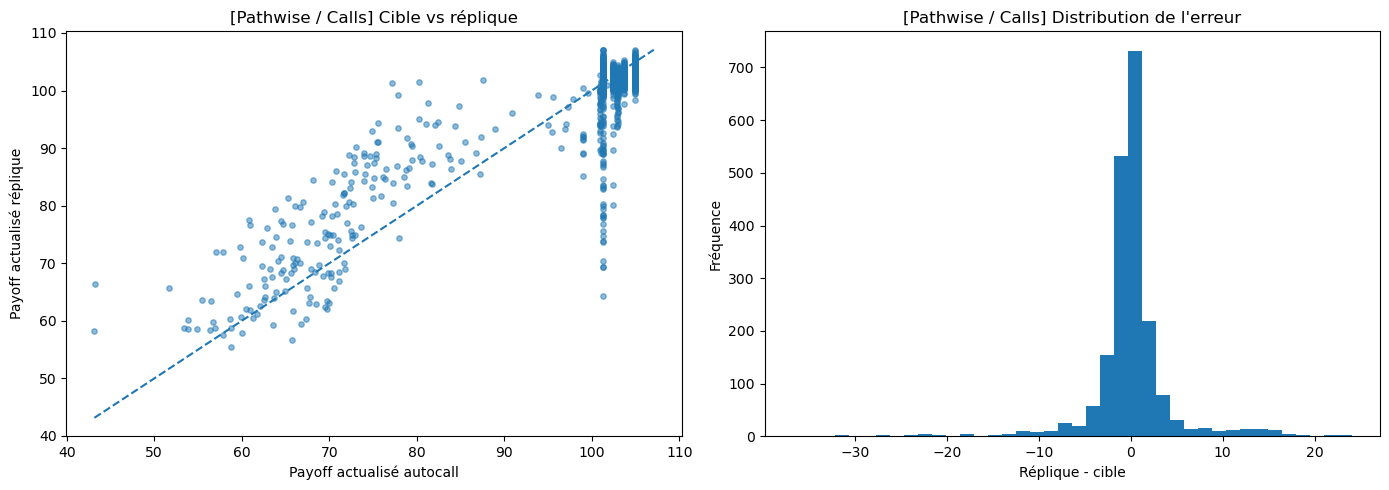

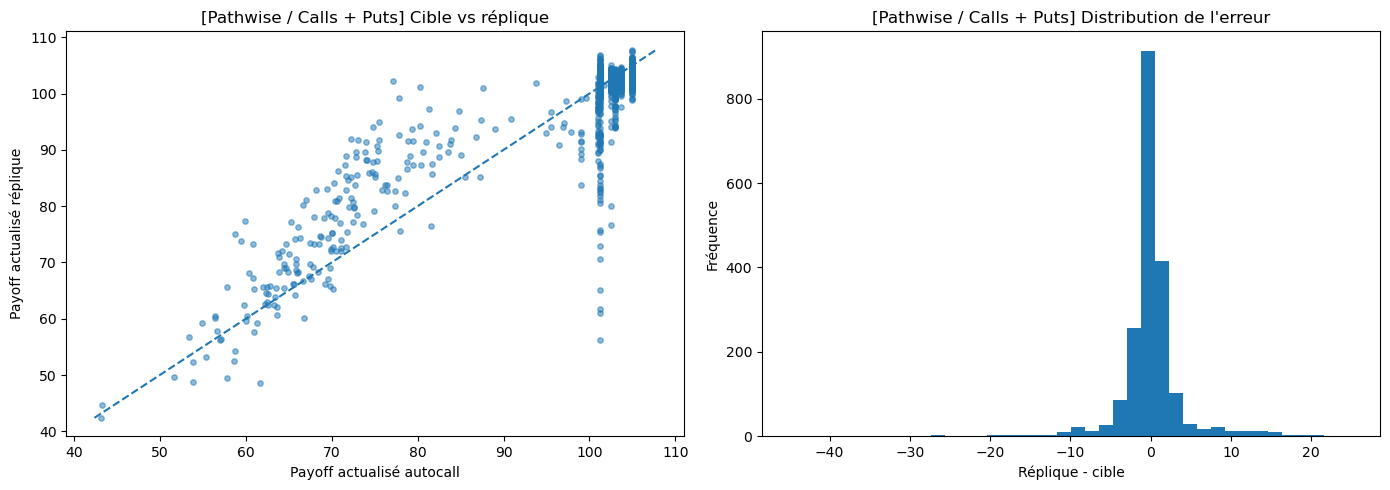

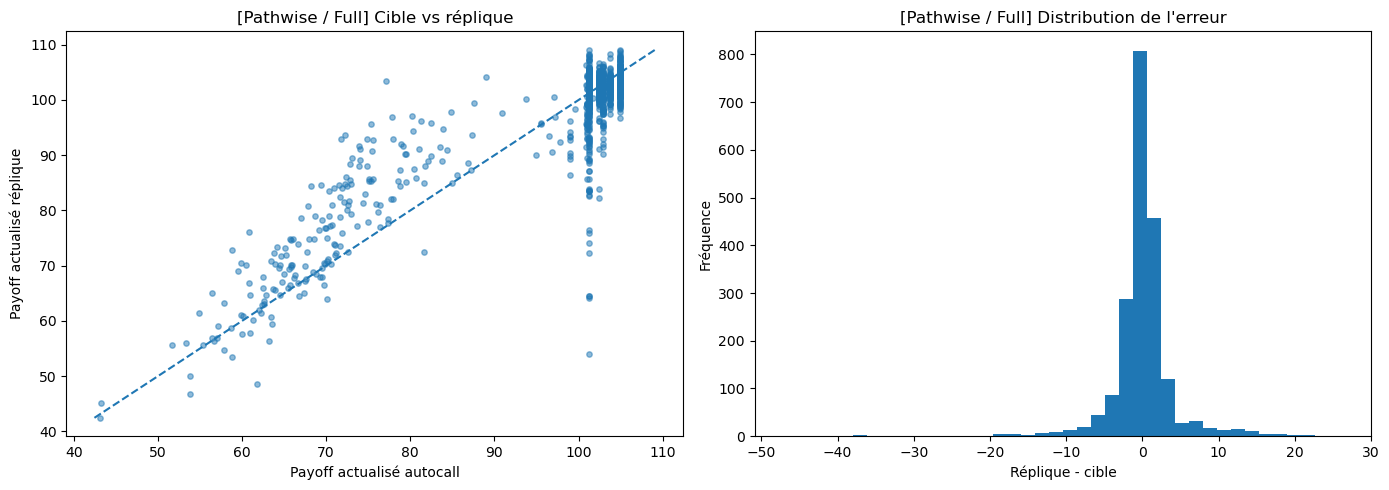

In [391]:
res_path_calls = run_naive_benchmark_payoff_pathwise(product=prod,spot0=spot0,valuation_date=valuation_date,maturity_date=maturity_date,rate=rate,dividend_yield=dividend_yield,vol=vol,family="calls",n_paths=2000,l2=1e-6)
res_path_calls_puts = run_naive_benchmark_payoff_pathwise(product=prod,spot0=spot0,valuation_date=valuation_date,maturity_date=maturity_date,rate=rate,dividend_yield=dividend_yield,vol=vol,family="calls_puts",n_paths=2000,l2=1e-6)
res_path_full = run_naive_benchmark_payoff_pathwise(product=prod,spot0=spot0,valuation_date=valuation_date,maturity_date=maturity_date,rate=rate,dividend_yield=dividend_yield,vol=vol,family="full",n_paths=2000,l2=1e-6)

print("Train:", res_path_calls["metrics_train"])
print("Test :", res_path_calls["metrics_test"])
display(res_path_calls["weights"].head(10))

print("Train:", res_path_calls_puts["metrics_train"])
print("Test :", res_path_calls_puts["metrics_test"])
display(res_path_calls_puts["weights"].head(10))

print("Train:", res_path_full["metrics_train"])
print("Test :", res_path_full["metrics_test"])
display(res_path_full["weights"].head(10))

plot_pathwise_benchmark(res_path_calls["y"],res_path_calls["replica"],title_prefix="[Pathwise / Calls] ")
plot_pathwise_benchmark(res_path_calls_puts["y"],res_path_calls_puts["replica"],title_prefix="[Pathwise / Calls + Puts] ")
plot_pathwise_benchmark(res_path_full["y"],res_path_full["replica"],title_prefix="[Pathwise / Full] ")

## 7. Grille d’entraînement

Le fit ne doit pas être fait uniquement au spot initial.  
C’est une erreur fréquente et trompeuse.

On entraîne le portefeuille sur une grille de points comprenant :

- plusieurs spots ;
- plusieurs temps résiduels ;
- plusieurs états du produit ;
- éventuellement plusieurs scénarios de volatilité ou de skew.

Cela permet de mesurer la qualité du fit non seulement localement, mais aussi en robustesse.

---

## 8. Régularisation

Le problème de fit est souvent mal conditionné.  
Il faut donc régulariser.

On peut utiliser par exemple :

$$
\min_w \|Aw - b\|^2 + \lambda \|w\|^2
$$

avec éventuellement :

- une pénalité de courbure sur les poids ;
- des contraintes de signe ;
- des contraintes de budget ;
- des contraintes de neutralité delta.

La régularisation n’est pas un détail technique : elle est essentielle pour obtenir un portefeuille interprétable et stable.

---

## 9. Critères d’évaluation

La première partie du notebook doit mesurer au moins :

- l’erreur de prix moyenne ;
- l’erreur maximale ;
- la stabilité des poids ;
- la sensibilité du fit au changement de spot ;
- la sensibilité du fit à la grille de calibration ;
- le comportement hors échantillon.

Un bon benchmark naïf n’est pas celui qui fit le mieux un seul point, mais celui qui se comporte de manière acceptable dans des conditions variées.

---

## 10. Lecture de cette baseline

Cette baseline doit être présentée comme un point de comparaison volontairement simple.

Elle ne cherche pas à exploiter toute la structure du produit.  
Elle cherche plutôt à montrer ce que permet, et surtout ce que ne permet pas, un fit direct par panier fini de vanilles.


## 11. Remarques pratiques

Les cellules suivantes construisent une petite partie “marché” du notebook. Si `yfinance` n’est pas installé, cette section s’arrête proprement sans faire planter le notebook.


## 12. Données de marché optionnelles

Cette étape est utile pour récupérer un historique de sous-jacent et une chaîne d’options de test. Elle n’est pas indispensable pour comprendre la logique de réplication, mais elle rend l’exemple plus concret.


## 13. Vérification sur un sous-jacent de marché

On prend ici un ticker de test pour illustrer la construction de l’univers de vanilles à partir de données observées.


## 14. Lecture de la chaîne d’options

L’objectif est de garder uniquement les colonnes utiles pour la suite : strike, bid, ask, volatilité implicite, volume et open interest.


## 15. Contrôle de robustesse

Cette partie sert surtout à vérifier que les données récupérées sont cohérentes avant de les utiliser dans une calibration.


## 16. Préparation du panier de vanilles

On regroupe les calls et les puts dans un seul tableau pour faciliter la construction d’un univers de réplication.


## 17. Nettoyage des colonnes

On garde volontairement peu de colonnes au départ pour éviter d’introduire du bruit inutile dans le notebook.


## 18. Dernier affichage avant calibration

Ce tableau résume l’univers de départ utilisé pour la suite des tests.


Historique spot :


Price,Close,High,Low,Open,Volume
Ticker,SPY,SPY,SPY,SPY,SPY
Date,,,,,
2026-06-23,733.580017,739.630005,732.299988,733.809998,66846800
2026-06-24,733.239990,739.950012,730.840027,735.169983,57439500
2026-06-25,734.299988,739.369995,729.599976,738.909973,53934400
2026-06-26,728.989990,736.530029,716.580017,728.950012,71034000
2026-06-29,741.000000,741.559998,732.090027,736.530029,58035200


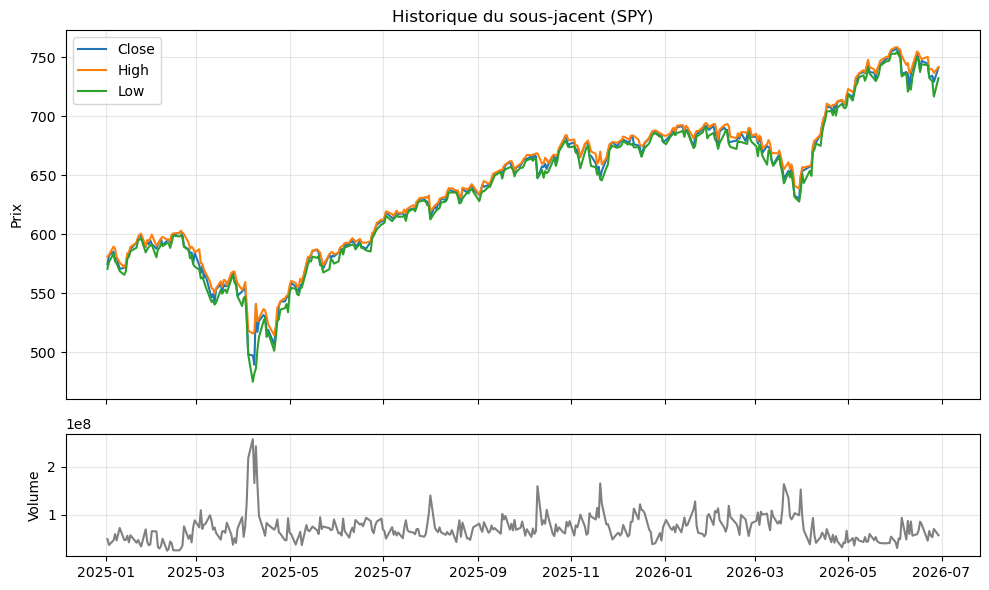

Maturities disponibles : ('2026-07-01', '2026-07-02', '2026-07-06', '2026-07-07', '2026-07-08', '2026-07-09', '2026-07-10', '2026-07-17', '2026-07-24', '2026-07-31', '2026-08-07', '2026-08-21', '2026-08-31', '2026-09-18', '2026-09-30', '2026-10-16', '2026-10-30', '2026-11-20', '2026-11-30', '2026-12-18', '2026-12-31', '2027-01-15', '2027-03-19', '2027-03-31', '2027-06-17', '2027-09-17', '2027-12-17', '2028-01-21', '2028-06-16', '2028-12-15')
Nombre de maturités : 30


,contractSymbol,kind,strike,lastPrice,impliedVolatility,Benchmark price BS
0,SPY260701C00540000,call,540.0,188.70,2.983401,205.784724
1,SPY260701C00545000,call,545.0,183.68,2.909182,200.754883
2,SPY260701C00550000,call,550.0,178.67,2.834964,195.721057
3,SPY260701C00555000,call,555.0,173.73,2.761722,190.689966
4,SPY260701C00560000,call,560.0,168.74,2.688480,185.654985
5,SPY260701C00565000,call,565.0,163.73,2.616214,180.623031
6,SPY260701C00580000,call,580.0,153.20,1.882813,162.498963
7,SPY260701C00585000,call,585.0,148.21,1.824220,157.485942
8,SPY260701C00590000,call,590.0,140.92,1.765626,152.471167
9,SPY260701C00595000,call,595.0,136.31,1.707033,147.454608


In [ ]:
ticker = "SPY"   # ou "AAPL"

if yf is None:      print("yfinance n'est pas installé dans cet environnement : la partie données de marché est ignorée.")
else:
    tk = yf.Ticker(ticker)

    # 1) Historique du sous-jacent
    spot_hist = yf.download(ticker,start="2025-01-01",end="2026-06-30",interval="1d",auto_adjust=True,progress=False)
    print("Historique spot :")
    display(spot_hist.tail())
    
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True,gridspec_kw={"height_ratios": [3, 1]})
    ax1.plot(spot_hist.index, spot_hist["Close"], label="Close")
    ax1.plot(spot_hist.index, spot_hist["High"], label="High")
    ax1.plot(spot_hist.index, spot_hist["Low"], label="Low")
    ax1.set_title(f"Historique du sous-jacent ({ticker})")
    ax1.set_ylabel("Prix")
    ax1.grid(True, alpha=0.3)
    ax1.legend()

    ax2.plot(spot_hist.index, spot_hist["Volume"], color="gray")
    ax2.set_ylabel("Volume")
    ax2.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    spot = spot_hist["Close"].dropna().iloc[-1].item()  # dernier cours de clôture disponible, utilisé comme spot de référence 
    valuation_date = pd.Timestamp(spot_hist.index[-1])

    # 2) Liste des maturités disponibles
    expiries = tk.options
    if not expiries:        print("Aucune maturité disponible pour ce ticker.")
    else:
        print("Maturities disponibles :", expiries[:])
        print("Nombre de maturités :", len(expiries))
        expiry = expiries[0]
        maturity = pd.Timestamp(expiry)

        # 3) Chaîne d'options
        chain = tk.option_chain(expiry)
        calls = chain.calls.copy()
        puts = chain.puts.copy()

        # 4) Construction d'un petit univers de vanilles
        calls["kind"] = "call"
        puts["kind"] = "put"
        vanillas_market = pd.concat([calls, puts], ignore_index=True)

        cols = [c for c in ["contractSymbol","kind","strike","lastPrice","impliedVolatility","expiration"] if c in vanillas_market.columns]
        vanillas_market = vanillas_market[cols].copy()
        
        
        # Prix Black-Scholes théorique ligne par ligne
        def _bs_price_row(row):
            sigma = row["impliedVolatility"]
            if pd.isna(sigma) or sigma <= 0:    return np.nan

            if row["kind"] == "call":   prod = EuropeanCall(name="tmp",strike=float(row["strike"]),maturity_date=maturity,notional=1.0)
            else:                       prod = EuropeanPut(name="tmp",strike=float(row["strike"]),maturity_date=maturity,notional=1.0)

            return prod.price_bs(spot, valuation_date, rate, dividend_yield, sigma)

        vanillas_market["Benchmark price BS"] = vanillas_market.apply(_bs_price_row, axis=1)
        display(vanillas_market.head(10))
